<a href="https://colab.research.google.com/github/eldhosekroy/churn_prediction/blob/main/Churn_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Import Libraries**

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
import warnings
import os
import time
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.tokenize import sent_tokenize

from sklearn.metrics import roc_curve, RocCurveDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import class_weight
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [172]:
output_dir = './output'

ARTIFACTS_PATH = output_dir
os.makedirs(ARTIFACTS_PATH, exist_ok=True)
print(f"Artifacts will be saved to: {ARTIFACTS_PATH}")

Artifacts will be saved to: ./output


#**Data Collection**

In [173]:
base_dir = os.getcwd()

input_dir = base_dir

enrolled_file = os.path.join(input_dir, 'Endrolled & registred.xlsx')
crm_file = os.path.join(input_dir, 'CRM-All contacts.xlsx')
notes_file = os.path.join(input_dir, 'All Notes-Contacts_copy.xlsx')

enrolled = pd.read_excel(enrolled_file)
crm = pd.read_excel(crm_file)
notes = pd.read_excel(notes_file)

##**Display datas**

In [174]:
enrolled.head()

,Contact Id,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Tag,...,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region,Whatsapp Number
0,zcrm_560042000000440092,zcrm_560042000000283001,SalesPerson-2,NaN,AJSAL Mohammed T S,False,NaN,NaN,Python Full stack,NaN,...,Male,NaN,NaN,False,False,Yes,NaN,NaN,NaN,NaN
1,zcrm_560042000000466061,zcrm_560042000000283001,SalesPerson-2,NaN,Abhishek R J,False,NaN,NaN,Datascience,NaN,...,Male,2022.0,NaN,False,False,NaN,NaN,NaN,NaN,NaN
2,zcrm_560042000000565094,zcrm_560042000000331113,SalesPerson-9,Alan,Thomas,False,NaN,NaN,NaN,NaN,...,Male,2023.0,NaN,False,False,Yes,NaN,NaN,NaN,NaN
3,zcrm_560042000000583691,zcrm_560042000000331113,SalesPerson-9,NaN,Abhinav,False,NaN,NaN,NaN,Ayisha,...,Male,2023.0,NaN,False,False,Yes,NaN,NaN,NaN,NaN
4,zcrm_560042000000604837,zcrm_560042000000283001,SalesPerson-2,NaN,Albin Shaji,False,NaN,NaN,NaN,Enrolled,...,Male,2024.0,0.0,False,True,Yes,NaN,NaN,NaN,NaN


In [175]:
crm.head()

,Contact Owner.id,Contact Owner,First Name,Last Name,Email Opt Out,college Name.id,college Name,Track Interested,Description,Created Time,...,Course,Gender,Year of Graduation,Experience,Test,Followup Email,Invoice,Mode of Program Joined,Program Location,Region
0,zcrm_560042000000283001,SalesPerson-2,NaN,man,False,NaN,NaN,NaN,NaN,2023-12-07 16:29:44,...,NaN,NaN,2024.0,NaN,False,False,Yes,NaN,NaN,NaN
1,zcrm_560042000000283001,SalesPerson-2,NaN,mahima,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
2,zcrm_560042000000283001,SalesPerson-2,NaN,feeba,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
3,zcrm_560042000000283001,SalesPerson-2,NaN,devadath,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN
4,zcrm_560042000000283001,SalesPerson-2,NaN,keerthy,False,NaN,NaN,Datascience,NaN,2023-12-07 17:02:32,...,NaN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN


In [176]:
notes.head()

,Note Id,Note Owner.id,Note Owner,Note Title,Note Content,Parent ID.id,Parent ID,Created By.id,Created By,Modified By.id,Modified By,Created Time,Modified Time
0,zcrm_560042000001333918,zcrm_560042000001286184,SalesPerson-21,NaN,SIJINA\nANOTHER CALLING,zcrm_560042000000424058,sijina,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:25:20,2024-05-29 12:25:20
1,zcrm_560042000001333864,zcrm_560042000001286184,SalesPerson-21,NaN,SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE,zcrm_560042000000424059,sonu,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:10:28,2024-05-29 12:10:28
2,zcrm_560042000001333760,zcrm_560042000001286184,SalesPerson-21,NaN,JOINED WORK,zcrm_560042000000424064,jainpaul,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 11:58:41,2024-05-29 11:58:41
3,zcrm_560042000001370043,zcrm_560042000001286184,SalesPerson-21,NaN,currently doing job,zcrm_560042000000424066,sanjeeth,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 14:35:33,2024-05-29 14:35:33
4,zcrm_560042000001333945,zcrm_560042000001286184,SalesPerson-21,NaN,SHILKA\nNOT CONNECTED,zcrm_560042000000424074,shilka,zcrm_560042000001286184,Udhya P U,zcrm_560042000001286184,Udhya P U,2024-05-29 12:27:35,2024-05-29 12:27:35


#**Data Exploration**

In [177]:
enrolled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Id              1274 non-null   object        
 1   Contact Owner.id        1274 non-null   object        
 2   Contact Owner           1274 non-null   object        
 3   First Name              152 non-null    object        
 4   Last Name               1274 non-null   object        
 5   Email Opt Out           1274 non-null   bool          
 6   college Name.id         65 non-null     object        
 7   college Name            65 non-null     object        
 8   Track Interested        556 non-null    object        
 9   Tag                     402 non-null    object        
 10  Description             68 non-null     object        
 11  Created By.id           1274 non-null   object        
 12  Modified By.id          1274 non-null   object  

In [178]:
enrolled.describe()

,Created Time,Modified Time,Last Activity Time,Unsubscribed Mode,Unsubscribed Time,Mailing Zip,Semester,Lead Generated on,Year of Graduation,Experience,Whatsapp Number
count,1274,1274,1274,0.0,0.0,3.000000,42.000000,848,319.000000,14.000000,4.000000e+00
mean,2025-03-02 01:55:06.603610624,2025-06-04 11:53:38.827315200,2025-06-15 06:58:25.073783296,NaN,NaN,679012.000000,5.023810,2024-11-02 04:43:35.094339584,2079.304075,0.071429,8.479450e+08
min,2023-12-07 16:29:44,2024-09-25 19:25:20,2024-09-25 19:25:20,NaN,NaN,673005.000000,2.000000,2003-06-10 00:00:00,2006.000000,0.000000,7.012189e+08
25%,2024-09-05 11:19:18,2025-01-22 12:24:57.500000,2025-01-22 14:49:26,NaN,NaN,677503.000000,4.000000,2024-06-23 00:00:00,2022.000000,0.000000,7.818011e+08
50%,2025-03-25 10:36:57.500000,2025-05-19 12:46:35,2025-05-19 12:50:00,NaN,NaN,682001.000000,6.000000,2024-11-04 12:00:00,2024.000000,0.000000,8.580451e+08
75%,2025-09-02 13:42:19.500000,2025-10-15 10:38:05,2025-10-15 10:38:06,NaN,NaN,682015.500000,6.000000,2025-07-01 00:00:00,2024.000000,0.000000,9.241890e+08
max,2026-02-23 11:44:53,2026-02-23 12:05:52,2026-02-24 17:14:04,NaN,NaN,682030.000000,8.000000,2026-02-23 00:00:00,20224.000000,1.000000,9.744707e+08
std,NaN,NaN,NaN,NaN,NaN,5202.234808,1.370207,NaN,1019.109883,0.267261,1.191900e+08


In [179]:
crm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46469 entries, 0 to 46468
Data columns (total 36 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Owner.id        46469 non-null  object        
 1   Contact Owner           46468 non-null  object        
 2   First Name              857 non-null    object        
 3   Last Name               46468 non-null  object        
 4   Email Opt Out           46469 non-null  bool          
 5   college Name.id         8360 non-null   object        
 6   college Name            8360 non-null   object        
 7   Track Interested        17914 non-null  object        
 8   Description             8924 non-null   object        
 9   Created Time            46469 non-null  datetime64[ns]
 10  Modified Time           46469 non-null  datetime64[ns]
 11  Last Activity Time      46162 non-null  datetime64[ns]
 12  Unsubscribed Mode       7 non-null      object

In [180]:
crm.describe()

,Created Time,Modified Time,Last Activity Time,Unsubscribed Time,Semester,Lead Generated on,Year of Graduation,Experience
count,46469,46469,46162,7,4170.000000,36338,6110.000000,641.000000
mean,2025-01-06 03:13:00.833028352,2025-05-09 08:14:01.382900224,2025-07-25 05:35:44.607837696,2025-12-03 05:27:53.571428608,7.027818,2024-07-15 01:44:25.176949760,2026.763175,34.951638
min,2023-12-07 16:29:44,2024-05-22 17:40:02,2024-05-22 17:40:02,2025-11-27 15:57:28,0.000000,1998-02-08 00:00:00,2.000000,0.000000
25%,2024-04-17 15:14:56,2024-09-25 19:57:09,2024-12-09 17:07:15.500000,2025-11-30 04:25:24,4.000000,2024-02-04 00:00:00,2023.000000,0.000000
50%,2025-02-08 10:39:42,2025-05-19 12:47:01,2025-09-30 18:25:16,2025-12-04 21:35:19,5.000000,2024-09-06 00:00:00,2024.000000,0.000000
75%,2025-08-19 12:35:45,2025-09-30 18:26:06,2026-01-23 11:00:34,2025-12-05 14:18:27,6.000000,2025-06-05 00:00:00,2025.000000,0.000000
max,2026-02-13 12:14:42,2026-02-13 12:14:42,2026-02-13 12:20:22,2025-12-08 11:14:46,2022.000000,2087-12-14 00:00:00,20224.000000,2024.000000
std,NaN,NaN,NaN,NaN,62.470446,NaN,333.541364,262.757842


In [181]:
notes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13627 entries, 0 to 13626
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Note Id         13627 non-null  object        
 1   Note Owner.id   13627 non-null  object        
 2   Note Owner      13627 non-null  object        
 3   Note Title      756 non-null    object        
 4   Note Content    13598 non-null  object        
 5   Parent ID.id    13627 non-null  object        
 6   Parent ID       13626 non-null  object        
 7   Created By.id   13627 non-null  object        
 8   Created By      13627 non-null  object        
 9   Modified By.id  13627 non-null  object        
 10  Modified By     13627 non-null  object        
 11  Created Time    13627 non-null  datetime64[ns]
 12  Modified Time   13627 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(11)
memory usage: 1.4+ MB


In [182]:
notes.describe()

,Created Time,Modified Time
count,13627,13627
mean,2025-07-01 22:25:00.722022400,2025-07-02 03:18:16.896382464
min,2023-12-13 16:49:00,2023-12-13 16:49:00
25%,2025-01-10 12:29:26.500000,2025-01-10 12:29:26.500000
50%,2025-11-14 10:13:34,2025-11-14 12:02:28
75%,2025-12-18 10:02:10.500000,2025-12-18 11:32:17
max,2026-02-13 12:18:48,2026-02-13 12:18:48


#**Data Pre-processing**

##**Data Cleaning**



*   Enrolled dataset








In [183]:
# checking null values for primary column
enrolled['Contact Id'].isnull().sum()

np.int64(0)

In [184]:
# checking duplicates values for primary column
enrolled['Contact Id'].duplicated().sum()

np.int64(0)

In [185]:
# checking duplicate values excluding contact_id column
enrolled.duplicated(subset=enrolled.columns.difference(['Contact Id'])).sum()

np.int64(0)

In [186]:
duplicate_rows = enrolled[enrolled.duplicated(subset=enrolled.columns.difference(['Contact Id']), keep=False)]
print(f"Number of duplicate rows (excluding 'Contact Id'): {len(duplicate_rows)}")
print(duplicate_rows.sort_values(by=list(enrolled.columns.difference(['Contact Id']))).head())

Number of duplicate rows (excluding 'Contact Id'): 0
Empty DataFrame
Columns: [Contact Id, Contact Owner.id, Contact Owner, First Name, Last Name, Email Opt Out, college Name.id, college Name, Track Interested, Tag, Description, Created By.id, Modified By.id, Created Time, Modified Time, Last Activity Time, Unsubscribed Mode, Unsubscribed Time, Contact Name, City, Mailing State, Mailing Zip, Mailing Country, Program Joined.id, Program Joined, Source of lead, Pipeline owner.id, Semester, Batch Assigned to, Lead Generated on, Course, Gender, Year of Graduation, Experience, Test, Followup Email, Invoice, Mode of Program Joined, Program Location, Region, Whatsapp Number]
Index: []

[0 rows x 41 columns]


In [187]:
# handling null values in different columns
# fill null values for 'invoice' column
enrolled['Invoice'] = enrolled['Invoice'].fillna('No')
enrolled['Invoice'] = enrolled['Invoice'].replace('yes', 'Yes')

# fill null values for 'program joined' column
enrolled['Program Joined'] = enrolled['Program Joined'].fillna('Not joined')

# fill null values for 'program location' column (mode)
mode_program_location = enrolled['Program Location'].mode()[0]
enrolled['Program Location'] = enrolled['Program Location'].fillna(mode_program_location)

# fill null values for 'experience' column
enrolled['Experience'] = enrolled['Experience'].fillna(0)

# fill null values for 'course' column
enrolled['Course'] = enrolled['Course'].fillna('Not mentioned')

# fill null values for 'lead generated on' column
# Sort the DataFrame by 'Lead Generated on' in ascending order
enrolled_sorted = enrolled.sort_values(by='Created Time', ascending=True)
# Fill null values in 'Lead Generated on' with the previous valid date
enrolled['Lead Generated on'] = enrolled_sorted['Lead Generated on'].ffill()
# Sort back to original index order if needed (optional, often good practice)
enrolled = enrolled.sort_index()

#fill null values for 'batch assigned to' column
enrolled['Batch Assigned to'] = enrolled['Batch Assigned to'].fillna('Not assigned')

#fill null values for 'source of lead' column
mode_source_of_lead = enrolled['Source of lead'].mode()[0]
enrolled['Source of lead'] = enrolled['Source of lead'].fillna(mode_source_of_lead)

#fill null values for 'tag' column
enrolled['Tag'] = enrolled['Tag'].fillna('Not mentioned')

#fill null values for 'description' column
enrolled['Description'] = enrolled['Description'].fillna('Not mentioned')

#fill null values for 'mode of program joined' column
enrolled['Mode of Program Joined'] = enrolled['Mode of Program Joined'].fillna('Not mentioned')

# standardising gender column
enrolled['Gender'] = enrolled['Gender'].replace('MAle', 'Male')

In [188]:
print("Unique values and their counts in the 'Program joined' column:")
print(enrolled['Program Joined'].value_counts(dropna=False))

Unique values and their counts in the 'Program joined' column:
Program Joined
Not joined                        239
Jan DA 2026                        48
Aug DS 2025                        40
Aug DA 2025                        39
Nov DA 2025                        38
                                 ... 
Oct One Month Programme 2025        1
Jan MERN 2026                       1
MERN Stack Jan25                    1
Nov One Month Programme 2025        1
Oct DA & DS Advanced programme      1
Name: count, Length: 85, dtype: int64


In [189]:
# Standardize the 'Program Joined' column
def standardize_program_joined_text(program_string):
    if pd.isna(program_string) or program_string == 'Not joined':
        return program_string

    program_string = str(program_string)

    # 1. Standardize month names (full to short form, and ensure proper case)
    month_mapping = {
        'January': 'Jan', 'February': 'Feb', 'March': 'Mar', 'April': 'Apr',
        'May': 'May', 'June': 'Jun', 'July': 'Jul', 'August': 'Aug',
        'September': 'Sep', 'October': 'Oct', 'November': 'Nov', 'December': 'Dec'
    }
    for full, short in month_mapping.items():
        program_string = re.sub(r'\b' + full + r'\b', short, program_string, flags=re.IGNORECASE)

    # Ensure month abbreviations are capitalized (e.g., "jan" -> "Jan")
    program_string = re.sub(r'\b(jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\b', lambda x: x.group(0).capitalize(), program_string, flags=0)

    # 2. Standardize common program keywords/abbreviations (case-insensitive search, consistent replacement)
    program_string = re.sub(r'\bprogramme\b', 'Program', program_string, flags=re.IGNORECASE)
    # Fix for 'Enrolleeee' issue: replace 'enroll' or 'enrollee' with 'Enrollee' (word boundary for accurate replacement)
    program_string = re.sub(r'\b(enroll|enrollee)\b', 'Enrollee', program_string, flags=re.IGNORECASE)

    # Specific course abbreviations - these should be uppercase
    program_string = re.sub(r'\bmern stack\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bmern\b', 'MERN', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytics\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata analytic\b', 'DA', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata science\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bdata sci\b', 'DS', program_string, flags=re.IGNORECASE)
    program_string = re.sub(r'\bfull stack\b', 'FS', program_string, flags=re.IGNORECASE)

    # Standardize 'One Month Program' variations
    program_string = re.sub(r'\b(One Month Programme|One Month Program)\b', 'One Month Program', program_string, flags=re.IGNORECASE)

    # Clean up extra spaces
    program_string = ' '.join(program_string.split())

    # Final capitalization for desired format (e.g., "DA May 2024"), then fix abbreviations
    program_string = program_string.title()
    program_string = program_string.replace('Da', 'DA').replace('Ds', 'DS').replace('Mern', 'MERN').replace('Fs', 'FS')
    # Ensure Enrollee keeps its capitalization
    program_string = program_string.replace('Enrollee', 'Enrollee')
    program_string = program_string.replace('One Month Program', 'One Month Program') # Keep as is after title()

    return program_string

# Apply this initial standardization to the 'Program Joined' column
enrolled['Program Joined'] = enrolled['Program Joined'].apply(standardize_program_joined_text)

In [190]:
print("Unique values and their counts in the 'Course' column:")
print(enrolled['Course'].value_counts(dropna=False))

Unique values and their counts in the 'Course' column:
Course
Not mentioned                                              861
BCA                                                         62
Btech-IT                                                    59
MCA                                                         58
BCom                                                        30
Btech-Non IT                                                25
MSc-IT                                                      24
BSc-IT                                                      20
Others                                                      16
MBA                                                         15
BSc-Non IT                                                  14
BVoc                                                        11
BA                                                          10
MSc-Non IT                                                   7
Mtech-IT                                                

In [191]:
# Function to standardize course names in the 'Course' column, focusing on preserving degree names
def standardize_course_name(course_string):
    if pd.isna(course_string) or str(course_string).strip().lower() == 'not mentioned':
        return 'NOT MENTIONED'

    course_string = str(course_string).upper()

    # Remove general noise: extra spaces, some punctuation, but be careful not to remove critical parts
    # Allow A-Z, 0-9, spaces, &, and hyphens. Only allow these characters
    course_string = re.sub(r'[^-A-Z0-9\s&]', '', course_string)
    course_string = ' '.join(course_string.split()) # Normalize spaces

    # Standardize common degree and course abbreviations
    course_string = course_string.replace('B.TECH', 'BTECH')
    course_string = course_string.replace('B.E.', 'BE')
    course_string = course_string.replace('M.TECH', 'MTECH')
    course_string = course_string.replace('BSC CS', 'BSC-CS')
    course_string = course_string.replace('MSC CS', 'MSC-CS')
    #course_string = course_string.replace('COMPUTER APPLICATION', 'CA')
    course_string = course_string.replace('BACHELOR OF COMPUTER APPLICATION - COMPUTER APPLICATION', 'BCA')
    # Add BVOC specific standardization
    course_string = course_string.replace('BVOC DATA ANALYTICS AND MACHINE LEARNING', 'B VOC-IT')
    course_string = course_string.replace('BVOC', 'B VOC') # General BVOC

    course_string = course_string.replace('COMPUTER SCIENCE AND ENGINEERING', 'BTECH')
    #course_string = course_string.replace('COMPUTER SCIENCE', 'BTECH')
    #course_string = course_string.replace('INFORMATION TECHNOLOGY', 'BTECH')
    course_string = course_string.replace('DATA ANALYTICS', 'DA')
    course_string = course_string.replace('DATA SCIENCE', 'DS')
    #course_string = course_string.replace('BIG DATA ANALYTICS', 'BDA')
    course_string = course_string.replace('ENGLISH LITERATURE', 'BA')
    course_string = course_string.replace('PLUS TWO', 'PLUS TWO')
    course_string = course_string.replace('DIPLOMA', 'DIPLOMA')
    course_string = course_string.replace('DIPLOMA-NON IT', 'DIPLOMA')

    # Handle common course name variations before general IT/NON-IT replacement
    course_string = course_string.replace('B TECH', 'BTECH') # For 'B TECH'
    course_string = course_string.replace('B_TECH', 'BTECH') # For 'B_TECH'
    course_string = course_string.replace('B_COM', 'BCOM') # For 'B_COM'
    course_string = course_string.replace('CA CA', 'CA')
    course_string = course_string.replace('CA-CA', 'CA') # For 'CA - CA' and 'CA CA'

    # Specific fixes for previous output issues (e.g., missing hyphens)
    course_string = course_string.replace('BTECHIT', 'BTECH')
    course_string = course_string.replace('MSCIT', 'MSC-IT')
    course_string = course_string.replace('BSCIT', 'BSC-IT')
    course_string = course_string.replace('MTECH-IT', 'MTECH')
    course_string = course_string.replace('MTECHIT', 'MTECH')

    # Address remaining specific MSC-CS-DA variations directly after initial replacements
    course_string = course_string.replace('MSC-CS DA', 'MSC-IT')
    course_string = course_string.replace('MSC-CSDA', 'MSC-IT')

    # These replacements should happen after primary acronym standardization
    # This line might create issues for standalone 'IT' if not careful. For now, keep as is as other specific replacements handle degree-IT combinations.
    course_string = course_string.replace(' IT', '-IT') # Handle BTech IT etc. to BTech-IT
    course_string = course_string.replace('NON-IT', '-NON-IT') # Handle BTech-Non IT etc.

    # Normalize hyphens: replace multiple hyphens with single, remove spaces around hyphens
    course_string = re.sub(r'-+', '-', course_string).strip('-')
    course_string = re.sub(r'\s*-\s*', '-', course_string) # Remove spaces around hyphens
    course_string = ' '.join(course_string.split()) # Final space normalization after hyphen cleanup

    # Special handling for numerical and very short entries
    if course_string == '2':
        return 'PLUS TWO'
    if course_string == 'COMP':
        return 'BCA'
    if course_string == 'POST GRADUATION':
        return 'PG'
    if course_string == 'BSC SCIENCE':
        return 'BSC'
    if course_string == 'GRADUATED':
        return 'GRADUATED'
    if course_string == 'DIPLOMA-IT':
        return 'DIPLOMA-IT'
    if course_string == 'DIPLOMA-NON-IT':
        return 'DIPLOMA'
    if course_string == 'DIPLOMA':
        return 'DIPLOMA'
    if course_string == 'INCOLLEGE' or course_string == 'IN_COLLEGE' or course_string == 'STUDENT': # Standardize IN_COLLEGE and convert 'STUDENT' if found as a course
        return 'UNSPECIFIED' # 'STUDENT' is a role, not a course
    if course_string == 'OTHERS':
        return 'OTHERS'

    # Remove words like 'PROGRAM', 'DEGREE', 'BACHELOR', 'MASTER' if they are standalone or don't contribute to specific degree names
    # This part should be less aggressive
    course_string = re.sub(r'\b(BACHELOR|MASTER|DEGREE|PROGRAMME|PROGRAM)\b', '', course_string).strip()
    course_string = re.sub(r'\b(OF|AND)\b', '', course_string).strip() # Remove common connectors

    course_string = ' '.join(course_string.split()) # Final space normalization

    # Map common variations to desired output, e.g., 'BTECH-IT' or 'BTECH'
    if 'BTECH' in course_string and 'NON' not in course_string and 'IT' not in course_string:
        course_string = 'BTECH'
    if 'BCA' in course_string:
        course_string = 'BCA'
    if 'MCA' in course_string:
        course_string = 'MCA'
    if 'BCOM' in course_string:
        course_string = 'BCOM'
    if 'MCOM' in course_string:
        course_string = 'MCOM'
    if 'BA' in course_string and 'DA' not in course_string and 'MBA' not in course_string:
        course_string = 'BA'
    if 'MA' in course_string:
        course_string = 'MA'
    if 'BSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string and 'COMPUTER SCIENCE' not in course_string:
        course_string = 'BSC'
    if 'MSC' in course_string and 'NON' not in course_string and 'IT' not in course_string and 'CS' not in course_string and 'COMPUTER SCIENCE' not in course_string and 'BIG' not in course_string:
        course_string = 'MSC'
    if 'CSE' in course_string:
        course_string = 'BTECH'
    if 'CS' in course_string and 'BSC' not in course_string and 'MSC' not in course_string:
        course_string = 'BTECH'
    if 'COMPUTER SCIENCE' in course_string and 'BSC' not in course_string and 'MSC' not in course_string:
        course_string = 'BTECH'
    if 'B VOC' in course_string:
        course_string = 'B VOC'
    if 'DIPLOMA'in course_string and 'IT' not in course_string:
        course_string = 'DIPLOMA'


    # Ensure consistency for entries like 'BTECH-IT', 'BSC-IT', etc.
    if course_string == 'BTECH-IT':
         course_string = 'BTECH'
    elif course_string == 'BTECH-NON-IT':
         course_string = 'BTECH'
    elif course_string == 'BACHELOR OF COMPUTER APPLICATION - COMPUTER APPLICATION':
         course_string = 'BCA'
    elif course_string == 'BSC-IT':
        pass # Keep as is
    elif course_string == 'MSC-IT':
        pass
    elif course_string == 'BSCSCIENCE':
         course_string = 'BSC'
    elif course_string == 'BSC COMPUTER SCIENCE':
         course_string = 'BSC-IT'
    elif course_string == 'MSC COMPUTER SCIENCEDA':
         course_string = 'MSC-IT'
    elif course_string == 'MSC COMPUTER SCIENCE DA':
         course_string = 'MSC-IT'
    elif course_string == 'MSC BIG DA':
         course_string = 'MSC-IT'
    elif course_string == 'MBA':
         course_string = 'MBA'
    elif course_string == 'MSC-NON-IT':
         course_string = 'MSC'
    elif course_string == 'BSC-NON-IT':
         course_string = 'BSC'
    elif course_string == 'DIPLOMA-IT':
        pass
    elif course_string == 'DIPLOMA':
        pass
    elif course_string == 'MSC-CS-DA':
         course_string = 'MSC-CS, DA'

    # Final check for empty strings or remaining generic terms
    if not course_string or course_string == 'NAN' or course_string == 'UNKNOWN' or course_string == 'UNSPECIFIED':
        return 'UNSPECIFIED'

    return course_string

enrolled['Course'] = enrolled['Course'].apply(standardize_course_name)


#**Feature Engineering**

In [192]:
# Creating new columns for easier analysis

## Extract year, month and program name
def extract_year_and_course(program_string):
    if pd.isna(program_string) or program_string == 'Not joined':
        return None, 'Not joined', None # Added None for month

    program_string = str(program_string)

    # Extract year
    year_match = re.search(r'\b(202[0-9]|203[0-9]|204[0-9])\b', program_string)
    year = int(year_match.group(1)) if year_match else None

    # Extract month (3-letter abbreviation)
    month_match = re.search(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', program_string)
    month = month_match.group(1) if month_match else None

    cleaned_course_name = program_string
    # Remove year and month abbreviations
    cleaned_course_name = re.sub(r'\b(Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\b', '', cleaned_course_name, flags=0)
    cleaned_course_name = re.sub(r'\b(202[0-9]|203[0-9]|204[0-9])\b', '', cleaned_course_name)

    # Aggressively remove common extra words, standalone numbers, and specific unwanted patterns
    extra_words_to_remove = [
        'Program', 'Enrollee', 'One Month', 'Advanced', 'Training', 'Bootcamp', 'Course', 'Classes',
        'Online', 'Offline', 'Batch', 'Session', 'Beginner', 'Intermediate', 'Expert', 'Module'
    ]
    # Remove these words case-insensitively
    cleaned_course_name = re.sub(r'\b(' + '|'.join(extra_words_to_remove) + r')\b', '', cleaned_course_name, flags=re.IGNORECASE)

    # Remove any standalone numbers (e.g., 'DA 25' -> 'DA ') or numbers attached to words (e.g., 'DA25' -> 'DA')
    cleaned_course_name = re.sub(r'\s*\d+\s*', ' ', cleaned_course_name) # Remove standalone numbers
    cleaned_course_name = re.sub(r'\b([A-Z]+)(\d+)\b', r'\1', cleaned_course_name) # Remove trailing numbers like 'DA25'

    cleaned_course_name = re.sub(r' & ', '&', cleaned_course_name) # Standardize ampersand
    cleaned_course_name = cleaned_course_name.strip()
    cleaned_course_name = ' '.join(cleaned_course_name.split()) # Remove multiple spaces
    cleaned_course_name = cleaned_course_name.upper() # Convert to uppercase for final standardization

    final_course_name = 'UNSPECIFIED'

    # Define primary course names to recognize as prefixes, sorted by length (descending)
    primary_course_names = [
        'ROUNDED DS&GENAI PROFESSIONAL', 'GEN AI&PROMPT ENG', 'WEB DEV', 'MERN', 'FULL STACK',
        'DATA ANALYTICS', 'DATA SCIENCE', 'DS&ALGORITHMS', 'PYTHON', 'MLOPS', 'AI', 'BA', 'DM', 'ML',
        'DA', 'DS', 'FS', 'PEP', 'PY'
    ]
    primary_course_names.sort(key=len, reverse=True) # Ensure longer names are checked first

    found_primary = False
    for pc_name in primary_course_names:
        # Check if the cleaned course name starts with a primary course name, or is exactly it
        if cleaned_course_name.startswith(pc_name) or cleaned_course_name == pc_name:
            final_course_name = pc_name
            found_primary = True
            break

    # If no primary course name was found by prefix, but the cleaned_course_name is not empty, use it as is or apply specific mappings
    if not found_primary and cleaned_course_name != '':
        course_name_exact_mapping = {
            'DATA ANALYTICS': 'DA',
            'DATA SCIENCE': 'DS',
            'FULL STACK': 'FS',
            'MERN STACK': 'MERN',
            'ADVANCED': 'ADVANCED',
            'EE': 'ENROLLEE',
            'DA ENROLLEE': 'DA'
        }
        final_course_name = course_name_exact_mapping.get(cleaned_course_name, cleaned_course_name)

    # Ensure 'Churned' overrides any other logic if the original program_string was 'Churned'
    if program_string == 'Not joined':
        final_course_name = 'Not joined'
    elif final_course_name == '': # If it became empty after all processing, default to UNSPECIFIED
        final_course_name = 'UNSPECIFIED'

    return year, final_course_name, month # Updated return to include month

# Apply the year and course extraction on the newly standardized 'Program Joined Standardized' column
enrolled[['Program_Year', 'Program_Name', 'Program_Month']] = enrolled['Program Joined'].apply(lambda x: pd.Series(extract_year_and_course(x))) # Updated assignment
enrolled['Program_Month'] = enrolled['Program_Month'].fillna('NA')



## Create the 'role' column based on conditional logic
def assign_role(row):
    if row['Experience'] > 0:
        return 'Professional'
    elif row['Semester'] > 0:
        return 'Student'
    elif row['Year of Graduation'] > 0 and row['Experience'] == 0:
        # Assuming a current year for 'Idle or Career Gap' if no experience but graduated
        # For simplicity, we'll just check if they graduated and have no experience
        return 'Idle or Career Gap'
    return 'Unknown'

enrolled['role'] = enrolled.apply(assign_role, axis=1)



## Create the 'background' column based on course
def assign_background(course):
    if pd.isna(course) or course == 'NOT MENTIONED' or course == 'UNSPECIFIED':
        return 'UNKNOWN'

    # Define lists of common tech and non-tech courses
    tech_keywords = [
        'BTECH', 'BE', 'MTECH', 'BCA', 'MCA', 'B VOC-IT', 'BSC-CS', 'MSC-CS', 'CSE', 'CS', 'IT', 'DA', 'DS', 'BDA',
        'MSCIT', 'BSCIT', 'MTECHIT', 'MSC-CS-DA', 'BTECH-IT', 'BSC-IT', 'DIPLOMA-IT'
    ]

    non_tech_keywords = [
        'BCOM', 'MCOM', 'BA', 'MBA', 'MA', 'B VOC', 'BSC', 'MSC', 'ENG LIT', 'PLUS TWO', 'DIPLOMA', 'PG',
        'BSC-NON-IT', 'DIPLOMA-NON-IT', 'GRADUATED', 'OTHERS'
    ]

    # Convert course to uppercase for case-insensitive matching
    course_upper = str(course).upper()

    for keyword in tech_keywords:
        if keyword in course_upper:
            return 'Tech'

    for keyword in non_tech_keywords:
        if keyword in course_upper:
            return 'Non-Tech'

    # If none of the above match, try to infer based on broader terms or default
    if 'TECH' in course_upper or 'SCIENCE' in course_upper or 'ENGINEERING' in course_upper:
        return 'Tech'
    elif 'ARTS' in course_upper or 'COMMERCE' in course_upper or 'HUMANITIES' in course_upper:
        return 'Non-Tech'

    return 'UNKNOWN'

enrolled['background'] = enrolled['Course'].apply(assign_background)

In [193]:
# fill null values of 'track interested' column
mode_track_interested = enrolled['Track Interested'].mode()[0]

enrolled.loc[
    enrolled['Track Interested'].isnull() & (enrolled['Program_Name'] != 'NOT JOINED'),
    'Track Interested'
] = enrolled['Program_Name']

# Fill any remaining null values in 'Track Interested' with the calculated mode
enrolled['Track Interested'] = enrolled['Track Interested'].fillna(mode_track_interested)

In [194]:
# Data type correction
float_columns = enrolled.select_dtypes(include=['float64']).columns

for col in float_columns:
    # Fill NaN values with 0 and then convert to integer
    enrolled[col] = enrolled[col].fillna(0).astype(int)

print("Data types after converting float columns to int:")
enrolled.info()

Data types after converting float columns to int:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Contact Id              1274 non-null   object        
 1   Contact Owner.id        1274 non-null   object        
 2   Contact Owner           1274 non-null   object        
 3   First Name              152 non-null    object        
 4   Last Name               1274 non-null   object        
 5   Email Opt Out           1274 non-null   bool          
 6   college Name.id         65 non-null     object        
 7   college Name            65 non-null     object        
 8   Track Interested        1274 non-null   object        
 9   Tag                     1274 non-null   object        
 10  Description             1274 non-null   object        
 11  Created By.id           1274 non-null   object        
 12

In [195]:
columns_to_display = [
    'Track Interested', 'Program Joined', 'Source of lead', 'Batch Assigned to',
    'Course', 'Gender', 'Mode of Program Joined', 'Program_Year', 'Program_Month',
    'Program_Name', 'role', 'background'
]

for col in columns_to_display:
    print(f"\nUnique values for column '{col}':")
    print(f"Number of unique values: {enrolled[col].nunique()}")
    print(pd.Series(enrolled[col].unique()))


Unique values for column 'Track Interested':
Number of unique values: 32
0                       Python Full stack
1                             Datascience
2                              Not joined
3                                      DA
4                                      DS
5                          Data Analytics
6                   Data Analytics Intern
7                              MERN Stack
8                  Data Analytics Fresher
9                           Not Mentioned
10                           Data Science
11                           Data Analyst
12                    Data Analyst Intern
13                                   MERN
14                          Dataanalytics
15                                    PEP
16              Datascience/DataAnalytics
17                           Dataanlytics
18                          DataAnalytics
19                         GenAI & Prompt
20                            UNSPECIFIED
21                     Prompt Engineering
22

#**Data Cleaning**

*   Notes dataset



In [196]:
# Fill null values for 'Note Title' in the notes dataset
notes['Note Title'] = notes['Note Title'].fillna('Not available')

# Fill null values for 'Note Content' in the notes dataset
notes['Note Content'] = notes['Note Content'].fillna('Not available')

#**Data Visualization and insight generation**

In [197]:
# KPI cards
total_candidates_contacted = crm.shape[0]
print(f"Total candidates contacted (number of rows in crm dataset): {total_candidates_contacted}")

Total candidates contacted (number of rows in crm dataset): 46469


In [198]:
invoice_counts = enrolled['Invoice'].value_counts()
registered_candidates = invoice_counts.get('Yes', 0)
enrolled_candidates = invoice_counts.sum()
unregistered_candidates = enrolled_candidates - registered_candidates

print("Unregistered candidates:", unregistered_candidates)
print("Registered candidates:", invoice_counts.get('Yes', 0))
print("Enrolled candidates:", invoice_counts.sum())

Unregistered candidates: 190
Registered candidates: 1084
Enrolled candidates: 1274


In [199]:
program_joined_counts = enrolled['Program Joined'].value_counts()

not_joined_candidates = program_joined_counts.get('Not joined', 0)
total_candidates = program_joined_counts.sum()
joined_candidates = total_candidates - not_joined_candidates

print("Candidates not joined in any program:", not_joined_candidates)
print("Joined candidates:", joined_candidates)

Candidates not joined in any program: 239
Joined candidates: 1035


In [200]:
program_joined_with_invoice_count = enrolled[(enrolled['Program Joined'] != 'Not joined') & (enrolled['Invoice'] == 'Yes')].shape[0]
print(f"Candidates who joined a program AND have an invoice (Active candidates): {program_joined_with_invoice_count}")

churned_program_invoice_status = enrolled[enrolled['Program Joined'] == 'Not joined']['Invoice'].value_counts()
churned_candidates = churned_program_invoice_status.get('Yes', 0)

print("Churned candidates (Invoice Yes, Program Not Joined):", churned_candidates)

churned_candidates_count = churned_program_invoice_status.get('Yes', 0)
active_candidates_count = program_joined_with_invoice_count # Updated to use program_joined_with_invoice_count

candidate_status_data = pd.Series({
    'Churned Candidates (Invoice Yes, Program not Joined)': churned_candidates_count,
    'Active Candidates (Joined Program)': active_candidates_count
})

joined_no_invoice = joined_candidates - active_candidates_count
print("Joined candidates without invoice:", joined_no_invoice)

non_active_candidates = churned_program_invoice_status.get('No', 0)
print("Inactive candidates (Invoice No, Program Not Joined):", non_active_candidates)

Candidates who joined a program AND have an invoice (Active candidates): 980
Churned candidates (Invoice Yes, Program Not Joined): 104
Joined candidates without invoice: 55
Inactive candidates (Invoice No, Program Not Joined): 135


### **Analysis of Notes Dataset**

In [201]:
# Download necessary NLTK data (run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
# Remove 'not' from stopwords to retain negation meaning
stop_words.discard('not')

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if pd.isna(text) or text == 'Not available':
        return []
    text = str(text).lower() # Lowercase
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenization
    words = [word for word in words if word not in stop_words] # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words] # Lemmatization
    return words

notes['cleaned_content'] = notes['Note Content'].apply(preprocess_text)

print("First 5 rows of notes with cleaned content:")
print(notes[['Note Content', 'cleaned_content']].head())

First 5 rows of notes with cleaned content:
                                   Note Content  \
0                       SIJINA\nANOTHER CALLING   
1  SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE   
2                                   JOINED WORK   
3                           currently doing job   
4                         SHILKA\nNOT CONNECTED   

                                     cleaned_content  
0                         [sijina, another, calling]  
1  [sonu, data, analytics, already, internship, d...  
2                                     [joined, work]  
3                                   [currently, job]  
4                           [shilka, not, connected]  



20 Most Common Words in Note Content:
rnr: 3063
not: 2014
looking: 1643
da: 1525
internship: 1487
pitched: 1443
interested: 1425
d: 1199
year: 1025
call: 919
decision: 909
pending: 885
job: 809
btech: 748
month: 621
done: 609
already: 602
working: 575
course: 514
college: 510
detail: 500
fu: 497
back: 455
paid: 442
intrested: 434
c: 429
data: 404
free: 401
seems: 396
online: 375
shared: 373
update: 353
currently: 350
busy: 343
completed: 323
bca: 319
ai: 317
project: 301
python: 280
mca: 273
luminar: 267
mern: 253
science: 246
bsc: 246
session: 238
final: 237
need: 232
msc: 231
university: 230
experience: 215


/tmp/ipykernel_801/1508714348.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=top_words_df, palette='viridis')


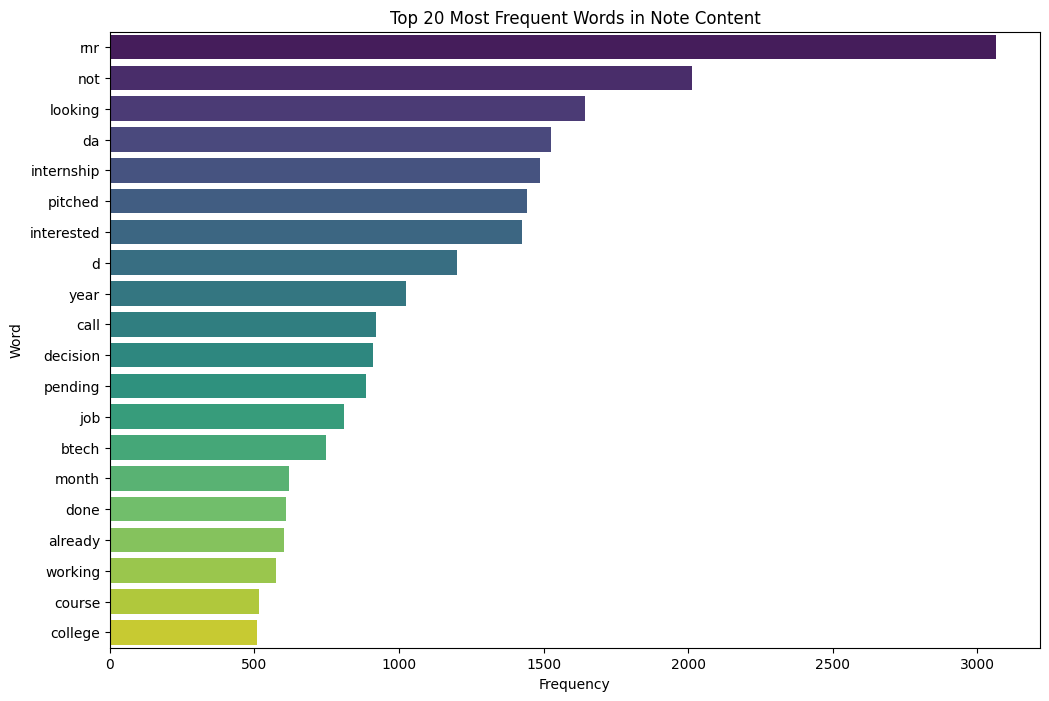

In [202]:
# word frequency analysis
# Combine all cleaned words into a single list
all_words = [word for sublist in notes['cleaned_content'] for word in sublist]

# Get the frequency of each word
word_counts = Counter(all_words)

# Display the 20 most common words
print("\n20 Most Common Words in Note Content:")
for word, count in word_counts.most_common(50):
    print(f"{word}: {count}")

# Visualize the top 20 words
top_words_df = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Word', data=top_words_df, palette='viridis')
plt.title('Top 20 Most Frequent Words in Note Content')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [203]:
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# frequent word context analsis
def get_sentences(text):
    if pd.isna(text) or text == 'Not available':
        return []

    text_str = str(text)

    # Replace newline characters with a period and space for better sentence tokenization
    # Handle both '\n' (literal) and '\n' (escaped) for robustness
    processed_text = re.sub(r'\\n+', '. ', text_str) # For escaped newlines
    processed_text = re.sub(r'\n+', '. ', processed_text)  # For actual newline characters
    # Clean up multiple periods that might result from successive newlines
    processed_text = re.sub(r'\s*\.\s*\.\s*', '. ', processed_text)
    # Ensure there's a space after periods for proper tokenization
    processed_text = re.sub(r'\.(?!\s)', '. ', processed_text)

    # Tokenize the processed text into sentences
    raw_sentences = sent_tokenize(processed_text)

    cleaned_sentences = []
    for sentence in raw_sentences:
        # Clean and strip the sentence for heuristic checks
        # Temporarily remove punctuation for a more accurate 'all-caps single word' check
        cleaned_s_for_check = re.sub(r'[^a-zA-Z0-9\s]', '', sentence).strip()

        # Heuristic to filter out potential 'names' or very short non-informative phrases
        # If a sentence becomes just one word after cleaning and is all uppercase (and not just a single letter), it's likely a name.
        words = cleaned_s_for_check.split()
        if len(words) == 1 and words[0].isupper() and len(words[0]) > 1:
            continue # Filter out single, all-caps words that are likely names (e.g., 'SIJINA')

        # If the original sentence (after stripping) is meaningful, add it
        if sentence.strip():
            cleaned_sentences.append(sentence.strip())

    return cleaned_sentences

notes['sentences'] = notes['Note Content'].apply(get_sentences)

print("First 5 rows of notes with tokenized sentences:")
print(notes[['Note Content', 'sentences']].head())

First 5 rows of notes with tokenized sentences:
                                   Note Content  \
0                       SIJINA\nANOTHER CALLING   
1  SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE   
2                                   JOINED WORK   
3                           currently doing job   
4                         SHILKA\nNOT CONNECTED   

                                  sentences  
0                         [ANOTHER CALLING]  
1  [DATA ANALYTICS ALREADY INTERNSHIP DONE]  
2                             [JOINED WORK]  
3                     [currently doing job]  
4                           [NOT CONNECTED]  


In [204]:
looking_sentences = []
for sentences_list in notes['sentences']:
    for sentence in sentences_list:
        if 'looking' in sentence.lower():
            looking_sentences.append(sentence)

print(f"Found {len(looking_sentences)} sentences containing 'looking'.\n")
print("Examples of sentences with 'looking':")
for i, sentence in enumerate(looking_sentences[:10]): # Display up to 10 examples
    print(f"- {sentence}")

Found 1669 sentences containing 'looking'.

Examples of sentences with 'looking':
- NOT LOOKING ANY INTRNSHIP .
- LOOKING FOR JOB ONLY
- looking for stipended internship
- NOT LOOKING FOR PAID INTERNSHIP
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- looking for job only
- looking for job only
- looking for a free internship .
- looking for stipend internship


In [205]:
def get_context_sentences(word, df, column='sentences', num_examples=5):
    found_sentences = []
    for sentences_list in df[column]:
        for sentence in sentences_list:
            if word.lower() in sentence.lower():
                found_sentences.append(sentence)

    print(f"\n--- Context for '{word}' ---")
    print(f"Found {len(found_sentences)} sentences containing '{word}'.")
    print(f"Examples of sentences with '{word}':")
    for i, sentence in enumerate(found_sentences[:num_examples]):
        print(f"- {sentence}")

# Analyze context for 'internship'
get_context_sentences('internship', notes)

# Analyze context for 'job'
get_context_sentences('job', notes)



--- Context for 'internship' ---
Found 1438 sentences containing 'internship'.
Examples of sentences with 'internship':
- DATA ANALYTICS ALREADY INTERNSHIP DONE
- NOT INTRESTED FOR INTERNSHIP
- ALREADY DONE INTERNSHIP FROM LUMINAR .
- looking for stipended internship
- NOT LOOKING FOR PAID INTERNSHIP

--- Context for 'job' ---
Found 815 sentences containing 'job'.
Examples of sentences with 'job':
- currently doing job
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- LOOKING FOR JOB ONLY
- looking for job only


##### **Extracting Reasons from Note Content**

In [206]:
def infer_status_and_reason_from_notes(sentences_list):
    full_note_text = ' '.join(sentences_list).lower()

    # Keywords for 'Joined' status - these should take highest precedence
    joined_keywords = [
        'enrolled', 'paid fees', 'paid the fees', 'will join today', 'joined', 'registered', 'starts program',
        'course started', 'confirmed admission', 'done payment', 'admission confirmed',
        'assessment', 'assessment attended', 'joined today', 'start classes', 'class started'
    ]

    # --- Not Joined Reasons Keywords ---
    competitor_names_list = ['luminar', 'avodha', 'smec', 'liuminar', 'techminds', 'soften', 'techolas', 'lumimar', 'other institute', 'lum', 'excelr', 'freshers job', 'xlr']
    completed_phrases_list = ['already done', 'already completed', 'already did', 'aloready completed', 'doing', 'percuing', 'done with internship'] # Typos considered

    # Keywords for "Join Later"
    join_later_keywords = ['join later', 'will join', 'joining next month', 'joining in', 'joining soon']
    month_names = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # New explicit phrases for "Details Shared/Collected (Candidate)"
    candidate_details_phrases = [
        'candidate details shared', 'student details shared', 'profile details shared',
        'contact details shared', 'information shared about candidate',
        'collected candidate details', 'collected student details', 'collected profile details',
        'collected contact details', 'collected information about candidate',
        'details shared with candidate', 'details collected from candidate'
    ]

    # Check for 'Joined' status first
    for keyword in joined_keywords:
        if keyword in full_note_text:
            return 'Joined', 'N/A'

    # --- Join Later Status Logic (moved to higher precedence) ---
    if any(keyword in full_note_text for keyword in join_later_keywords):
        return 'Join Later', 'N/A'
    # Check for 'month name later' pattern
    for month in month_names:
        if re.search(r'\b' + month + r'\s+later\b', full_note_text):
            return 'Join Later', 'N/A'

    # --- Not Joined Reasons Logic ---

    # Priority 1: Specific check for 'Joined Competitor' when combined with 'already done' or 'already completed'
    found_competitor_keyword = any(comp_name in full_note_text for comp_name in competitor_names_list)
    found_completed_phrase = any(comp_phrase in full_note_text for comp_phrase in completed_phrases_list)

    if found_competitor_keyword and found_completed_phrase:
        return 'Not Joined', 'Joined Competitor'

    # Priority 2: Other 'Not Joined' reasons
    not_joined_reasons = {
        'Joined Competitor': [
            'lum', 'luminar', 'avodha', 'excelr', 'smec', 'liuminar', 'techminds', 'soften', 'joined competitor', 'other institute', 'lumimar', 'techolas',
            'freshers job'
        ],
        'Already Working/Internship': [
            'already working', 'already job', 'technopark', 'infopark', 'doing job', 'doing internship', 'working experience', 'placed', 'joined work', 'already internship done', 'currently working',
            'working as a', 'current job', 'previous job', 'passed out', 'got job', 'job offer'
        ],
        'Looking for Job/Internship (Specific Type)': [
            'looking for job', 'job only', 'looking for internship', 'internship only', 'looking for stipended internship',
            'looking for stipend', 'looking for stipended', 'free internship', 'only job', 'only internship', 'stipend internship', 'paid internship'
        ],
        'Not Interested': [
            'not interested', 'no interest', 'not joining', 'not join', 'not intrested for internship', 'not wish to join'
        ],
        'Financial Issue': [
            'fees', 'amount issue', 'money issue', 'expensive', 'cost', 'financial issue', 'fee issue', 'no money', 'low salary', 'salary issue'
        ],
        'Unreachable/Not Connected': [
            'not connected', 'unreachable', 'no network', 'switched off', 'rnr', 'wrong number', 'unanswered', 'no response', 'unresponsive', 'call later', 'not answering',
            'not responding', 'dis call', 'not reachable', 'nc', 'busy', 'call not connected', 'disconnected', 'switch off', 'incoming calls', 'incoming not', 'junk',
            'na', 'invalid', 'rejected', 'not respond', 'out of service', 'wrong number', 'incoming', 'not connecting', 'voice mail', 'voice issue', 'bc', 'wrong no',
            'network issue', 'out of network', 'rhr', 'disconnecting', 'blocked', 'r rn', 'rne', 'not attended', 'callbusy', 'not ringing', 'discall', 'nr', 'r n r'
        ],
        'Decision Pending/Discussing': [
            'decision pending', 'decission pending', 'thinking', 'will inform', 'call back', 'discuss with family', 'discuss with parents', 'will confirm', 'pending decision'
        ],
        'Location Issue': [
            'location issue', 'migrate', 'relocate', 'far away', 'different city', 'distance issue', 'shifted location'
        ],
        'Time/Schedule Conflict': [
            'time issue', 'schedule conflict', 'busy', 'clash', 'no time', 'exam time', 'studies'
        ]
    }

    for reason, keywords in not_joined_reasons.items():
        for keyword in keywords:
            if keyword in full_note_text:
                if reason == 'Looking for Job/Internship (Specific Type)' and any(ni_key in full_note_text for ni_key in ['not interested', 'no interest']):
                    return 'Not Joined', 'Looking for Other Opportunity (Not Interested)'
                return 'Not Joined', reason

    # --- Unclear Status Logic ---
    # Handle "Details Shared/Collected (Candidate)" with explicit phrases
    if any(phrase in full_note_text for phrase in candidate_details_phrases):
        return 'Unclear', 'Details Shared/Collected (Candidate)'


    # If neither joined nor a clear not-joined reason, check for general interest/pending
    if 'interested' in full_note_text or 'enquiring' in full_note_text or 'waiting' in full_note_text or 'more details' in full_note_text:
        return 'Unclear', 'Interested/Pending'

    # Default to 'Unclear' if no definitive status or reason found
    return 'Unclear', 'Other/Unspecified'


# Apply the new function to the notes DataFrame
notes[['inferred_status', 'inferred_reason']] = notes['sentences'].apply(lambda x: pd.Series(infer_status_and_reason_from_notes(x)))

print("First 50 notes with inferred status and reason:")
print(notes[['Note Content', 'inferred_status', 'inferred_reason']].head(50))

print("\nInferred Status distribution:")
print(notes['inferred_status'].value_counts())

First 50 notes with inferred status and reason:
                                         Note Content inferred_status  \
0                             SIJINA\nANOTHER CALLING         Unclear   
1        SONU\nDATA ANALYTICS ALREADY INTERNSHIP DONE      Not Joined   
2                                         JOINED WORK          Joined   
3                                 currently doing job      Not Joined   
4                               SHILKA\nNOT CONNECTED      Not Joined   
5                           VISHNU CALL NOT ANSWERING      Not Joined   
6   RESOURCE \nPLUS TWO\n2017\nBACKERY SHOP\nIDUKK...         Unclear   
7   software testing from liuminar and pfs from av...      Not Joined   
8                          datascience from techminds      Not Joined   
9                                bigdata from lumimar      Not Joined   
10             already done 1 year prgrm from luminar      Not Joined   
11                           datascience from luminar      Not Joined   
12 

In [207]:
print("\nInferred Reason distribution for all notes:")
print(notes['inferred_reason'].value_counts())


Inferred Reason distribution for all notes:
inferred_reason
Other/Unspecified                                 5482
Unreachable/Not Connected                         4100
Decision Pending/Discussing                        916
Not Interested                                     689
Looking for Job/Internship (Specific Type)         679
Joined Competitor                                  570
Already Working/Internship                         395
Interested/Pending                                 305
N/A                                                266
Looking for Other Opportunity (Not Interested)     161
Financial Issue                                     45
Time/Schedule Conflict                              11
Location Issue                                       8
Name: count, dtype: int64


Number of notes inferred as 'Not Joined': 7574

Inferred Reasons for Not Joining:
                                           Reason  Count
0                       Unreachable/Not Connected   4100
1                     Decision Pending/Discussing    916
2                                  Not Interested    689
3      Looking for Job/Internship (Specific Type)    679
4                               Joined Competitor    570
5                      Already Working/Internship    395
6  Looking for Other Opportunity (Not Interested)    161
7                                 Financial Issue     45
8                          Time/Schedule Conflict     11
9                                  Location Issue      8


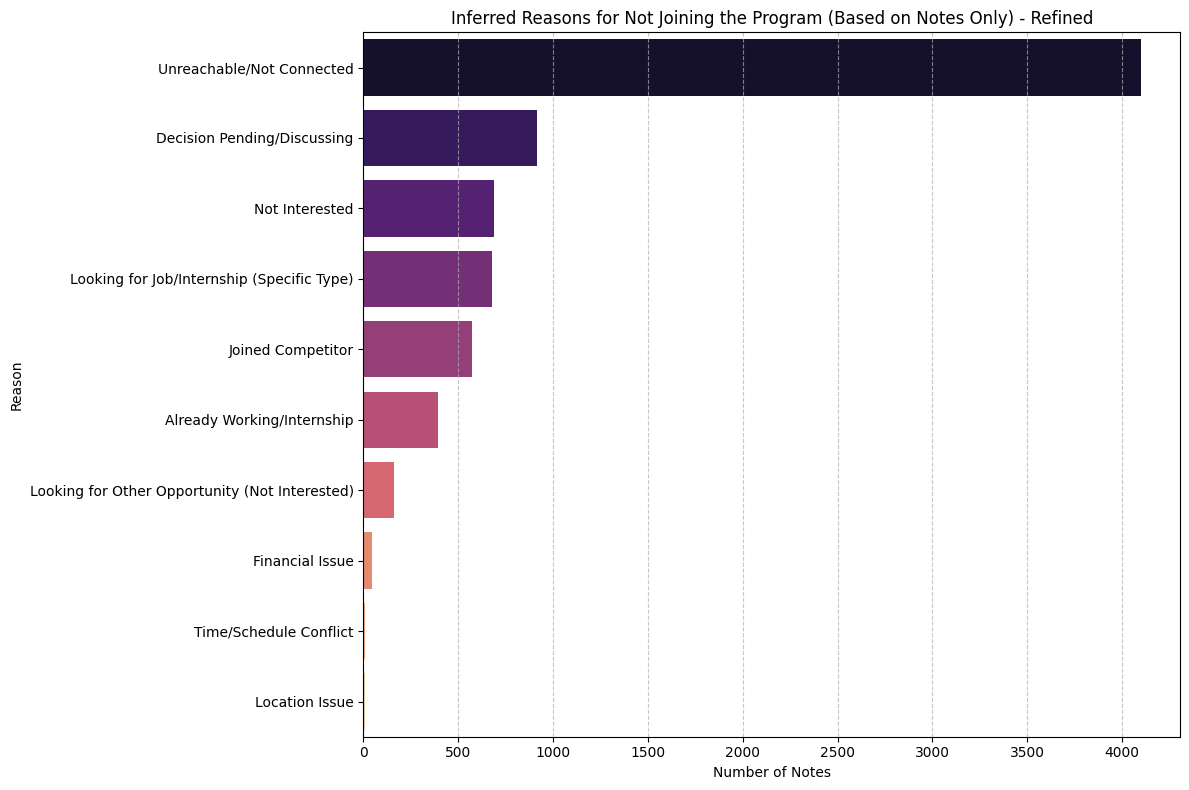

In [208]:
notes_non_joiners_inferred = notes[notes['inferred_status'] == 'Not Joined'].copy()

print(f"Number of notes inferred as 'Not Joined': {len(notes_non_joiners_inferred)}")

# Get value counts for inferred reasons
inferred_reason_counts = notes_non_joiners_inferred['inferred_reason'].value_counts().reset_index()
inferred_reason_counts.columns = ['Reason', 'Count']

print("\nInferred Reasons for Not Joining:")
print(inferred_reason_counts)

# Visualize the inferred reasons
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Reason', data=inferred_reason_counts, palette='magma', hue='Reason', legend=False) # Added hue for clarity
plt.title('Inferred Reasons for Not Joining the Program (Based on Notes Only) - Refined')
plt.xlabel('Number of Notes')
plt.ylabel('Reason')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [209]:
# analysis to find whether candidate attended induction section
induction_keywords = ['induction', 'onboarding', 'orientation', 'joining process', 'join date', 'commencement']

for keyword in induction_keywords:
    get_context_sentences(keyword, notes, num_examples=5)


--- Context for 'induction' ---
Found 0 sentences containing 'induction'.
Examples of sentences with 'induction':

--- Context for 'onboarding' ---
Found 0 sentences containing 'onboarding'.
Examples of sentences with 'onboarding':

--- Context for 'orientation' ---
Found 0 sentences containing 'orientation'.
Examples of sentences with 'orientation':

--- Context for 'joining process' ---
Found 0 sentences containing 'joining process'.
Examples of sentences with 'joining process':

--- Context for 'join date' ---
Found 0 sentences containing 'join date'.
Examples of sentences with 'join date':

--- Context for 'commencement' ---
Found 0 sentences containing 'commencement'.
Examples of sentences with 'commencement':


###**Analysis of enrolled dataset**

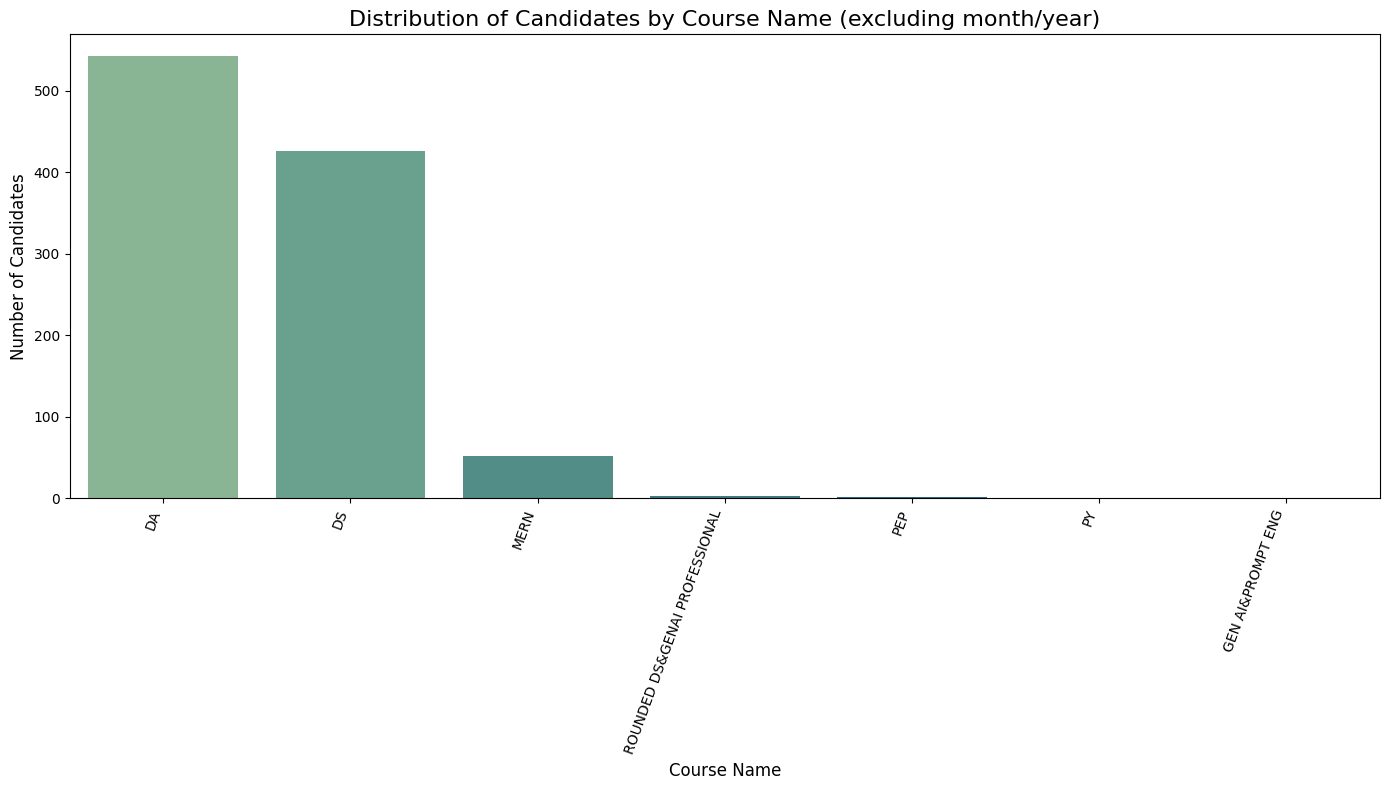

In [210]:
program_name_distribution = enrolled[(enrolled['Program_Name'] != 'Not joined') & (enrolled['Program_Name'] != 'UNSPECIFIED')]
program_name_counts = program_name_distribution['Program_Name'].value_counts()

plt.figure(figsize=(14, 8)) # Increased figure size
sns.barplot(x=program_name_counts.index, y=program_name_counts.values, hue=program_name_counts.index, palette='crest', legend=False)
plt.title('Distribution of Candidates by Course Name (excluding month/year)', fontsize=16)
plt.xlabel('Course Name', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=70, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Candidates who joined a program AND have an invoice (Active candidates): 980
Churned candidates (Invoice Yes, Program Joined Churned): 104
Joined candidates without invoice: 55
Inactive candidates (Invoice No, Program Joined Churned): 135


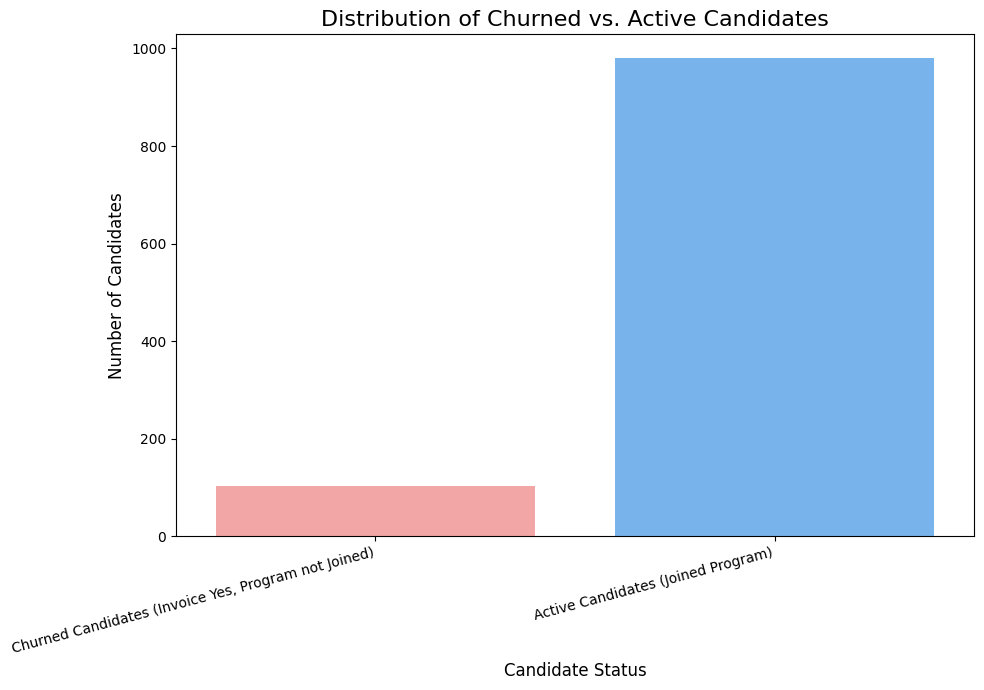

In [211]:
program_joined_with_invoice_count = enrolled[(enrolled['Program Joined'] != 'Not joined') & (enrolled['Invoice'] == 'Yes')].shape[0]
print(f"Candidates who joined a program AND have an invoice (Active candidates): {program_joined_with_invoice_count}")

churned_program_invoice_status = enrolled[enrolled['Program Joined'] == 'Not joined']['Invoice'].value_counts()
churned_candidates = churned_program_invoice_status.get('Yes', 0)

print("Churned candidates (Invoice Yes, Program Joined Churned):", churned_candidates)

churned_candidates_count = churned_program_invoice_status.get('Yes', 0)
active_candidates_count = program_joined_with_invoice_count # Updated to use program_joined_with_invoice_count

candidate_status_data = pd.Series({
    'Churned Candidates (Invoice Yes, Program not Joined)': churned_candidates_count,
    'Active Candidates (Joined Program)': active_candidates_count
})

joined_no_invoice = joined_candidates - active_candidates_count
print("Joined candidates without invoice:", joined_no_invoice)

non_active_candidates = churned_program_invoice_status.get('No', 0)
print("Inactive candidates (Invoice No, Program Joined Churned):", non_active_candidates)


plt.figure(figsize=(10, 7))
sns.barplot(x=candidate_status_data.index, y=candidate_status_data.values, hue=candidate_status_data.index, palette=['#ff9999', '#66b3ff'], legend=False)
plt.title('Distribution of Churned vs. Active Candidates', fontsize=16)
plt.xlabel('Candidate Status', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

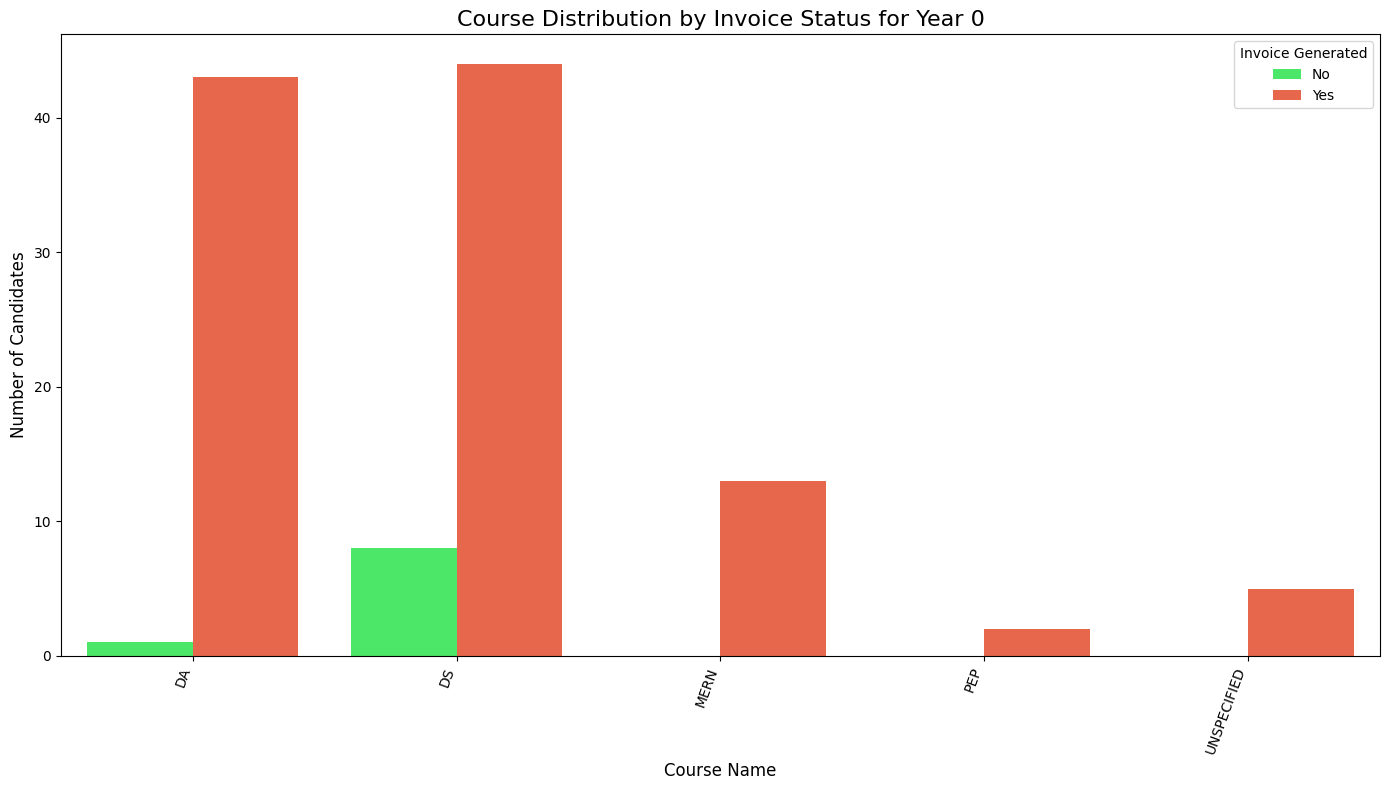

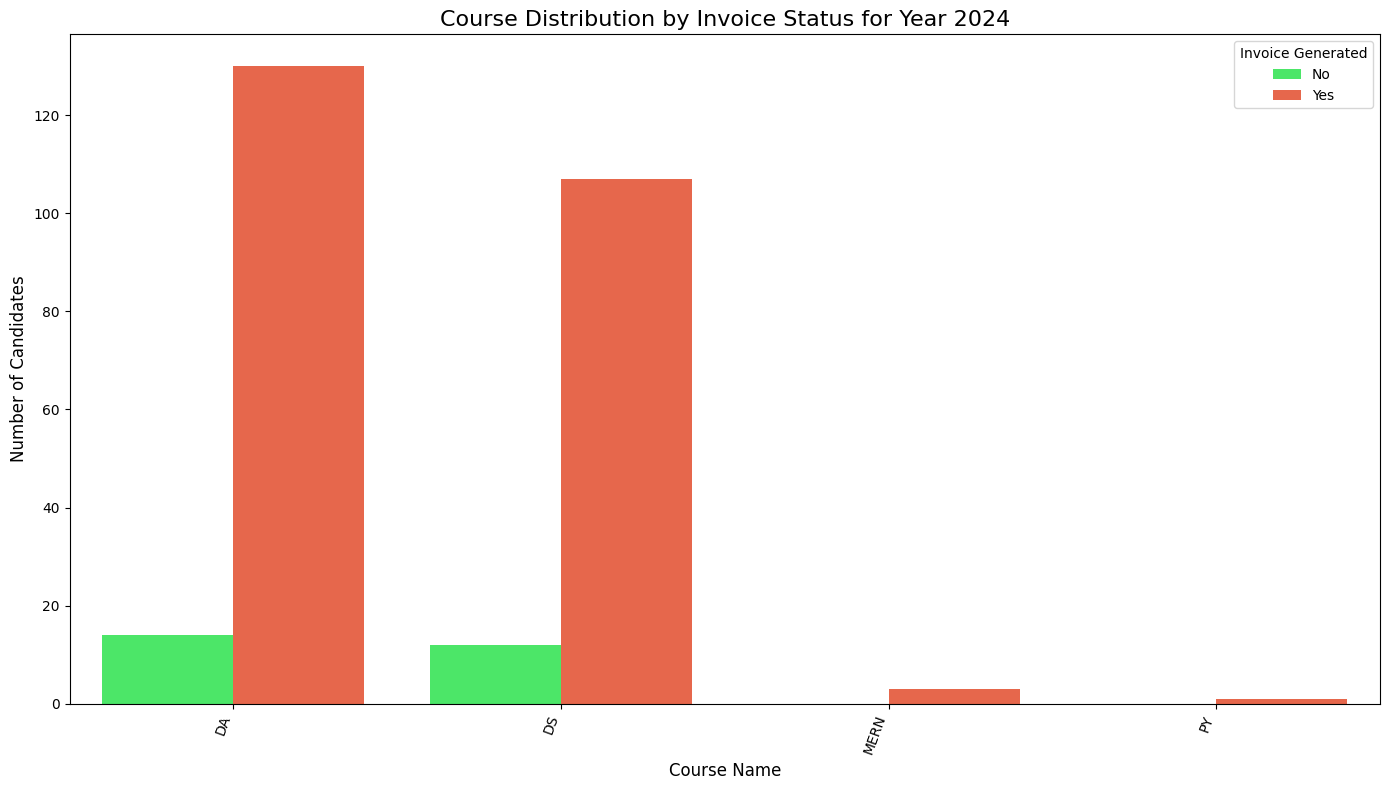

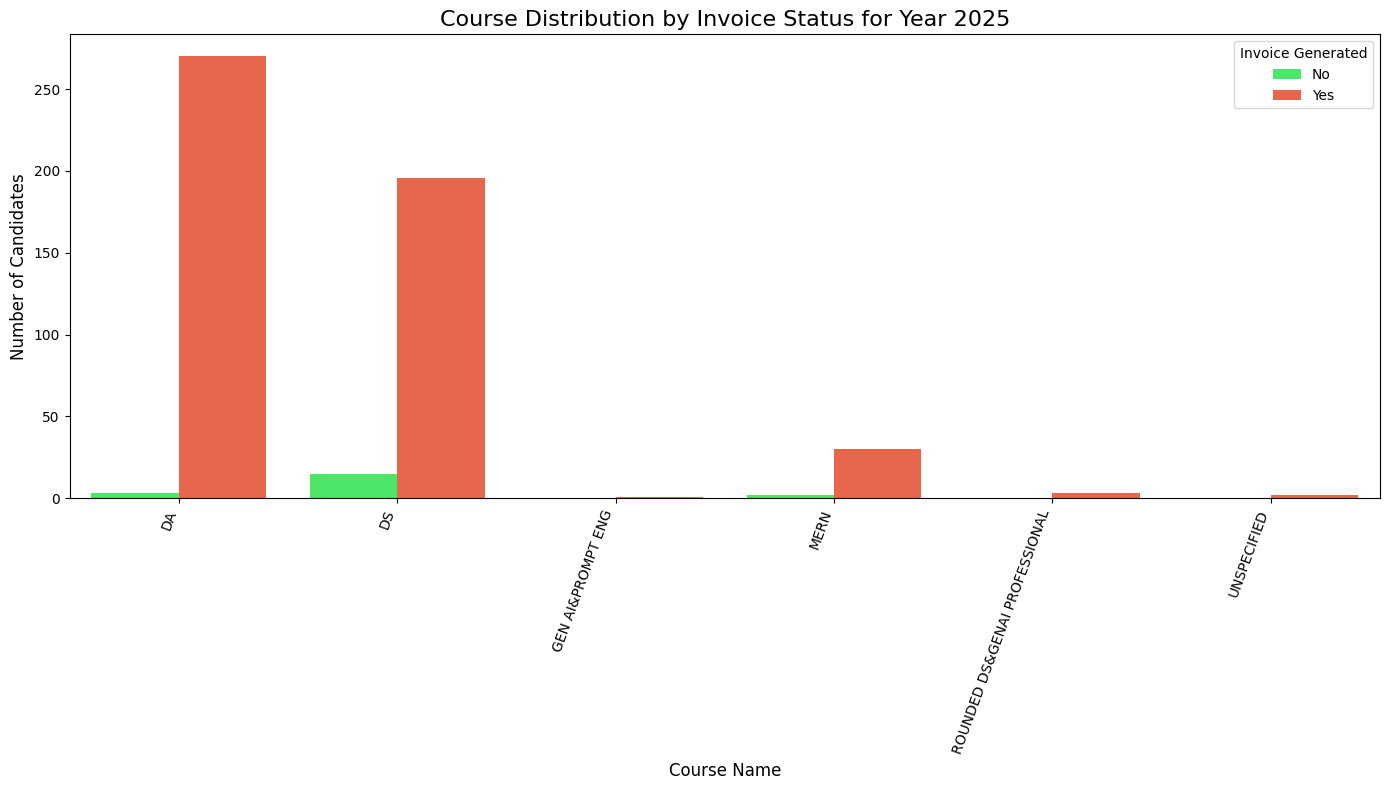

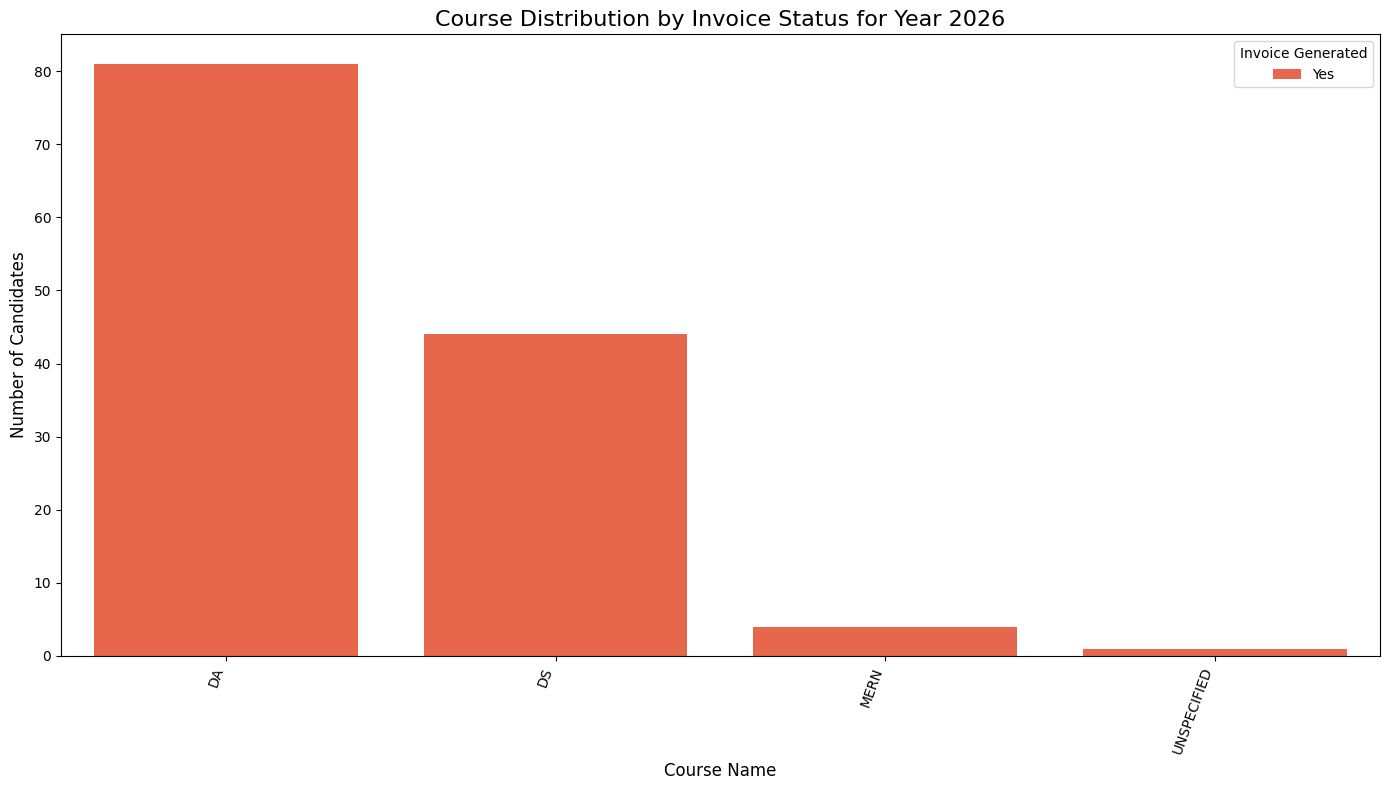

In [212]:
# Filter out 'Churned' courses and entries with NaN years for visualization
# Assuming 'enrolled' DataFrame, 'Course_Name', 'Program_Year', and 'Invoice' are already prepared from previous steps.
program_data_for_plot = enrolled[enrolled['Program_Name'] != 'Not joined'].dropna(subset=['Program_Year']).copy()
program_data_for_plot['Program_Year'] = program_data_for_plot['Program_Year'].astype(int)

# Get unique years for plotting
unique_years_for_plot = sorted(program_data_for_plot['Program_Year'].unique())

for year in unique_years_for_plot:
    year_data = program_data_for_plot[program_data_for_plot['Program_Year'] == year]

    # Group by Course_Name and Invoice status, then count
    course_invoice_counts = year_data.groupby(['Program_Name', 'Invoice']).size().unstack(fill_value=0)

    if not course_invoice_counts.empty:
        # Prepare data for seaborn.barplot with hue
        # 'level_1' is the default name for the stacked column if no other name is specified. It corresponds to 'Invoice'.
        plot_df = course_invoice_counts.stack().reset_index(name='Count')

        plt.figure(figsize=(14, 8)) # Increased figure size for better readability
        sns.barplot(
            data=plot_df,
            x='Program_Name',
            y='Count',
            hue='Invoice', # Use the 'Invoice' column directly for hue
            palette={'Yes': '#FF5733', 'No': '#33FF57'} # Using brighter, more distinct colors
        )
        plt.title(f'Course Distribution by Invoice Status for Year {year}', fontsize=16)
        plt.xlabel('Course Name', fontsize=12)
        plt.ylabel('Number of Candidates', fontsize=12)
        plt.xticks(rotation=70, ha='right')
        plt.legend(title='Invoice Generated') # Add a legend for Invoice Status
        plt.tight_layout()
        plt.show()
    else:
        print(f'No course data available for year {year}.')


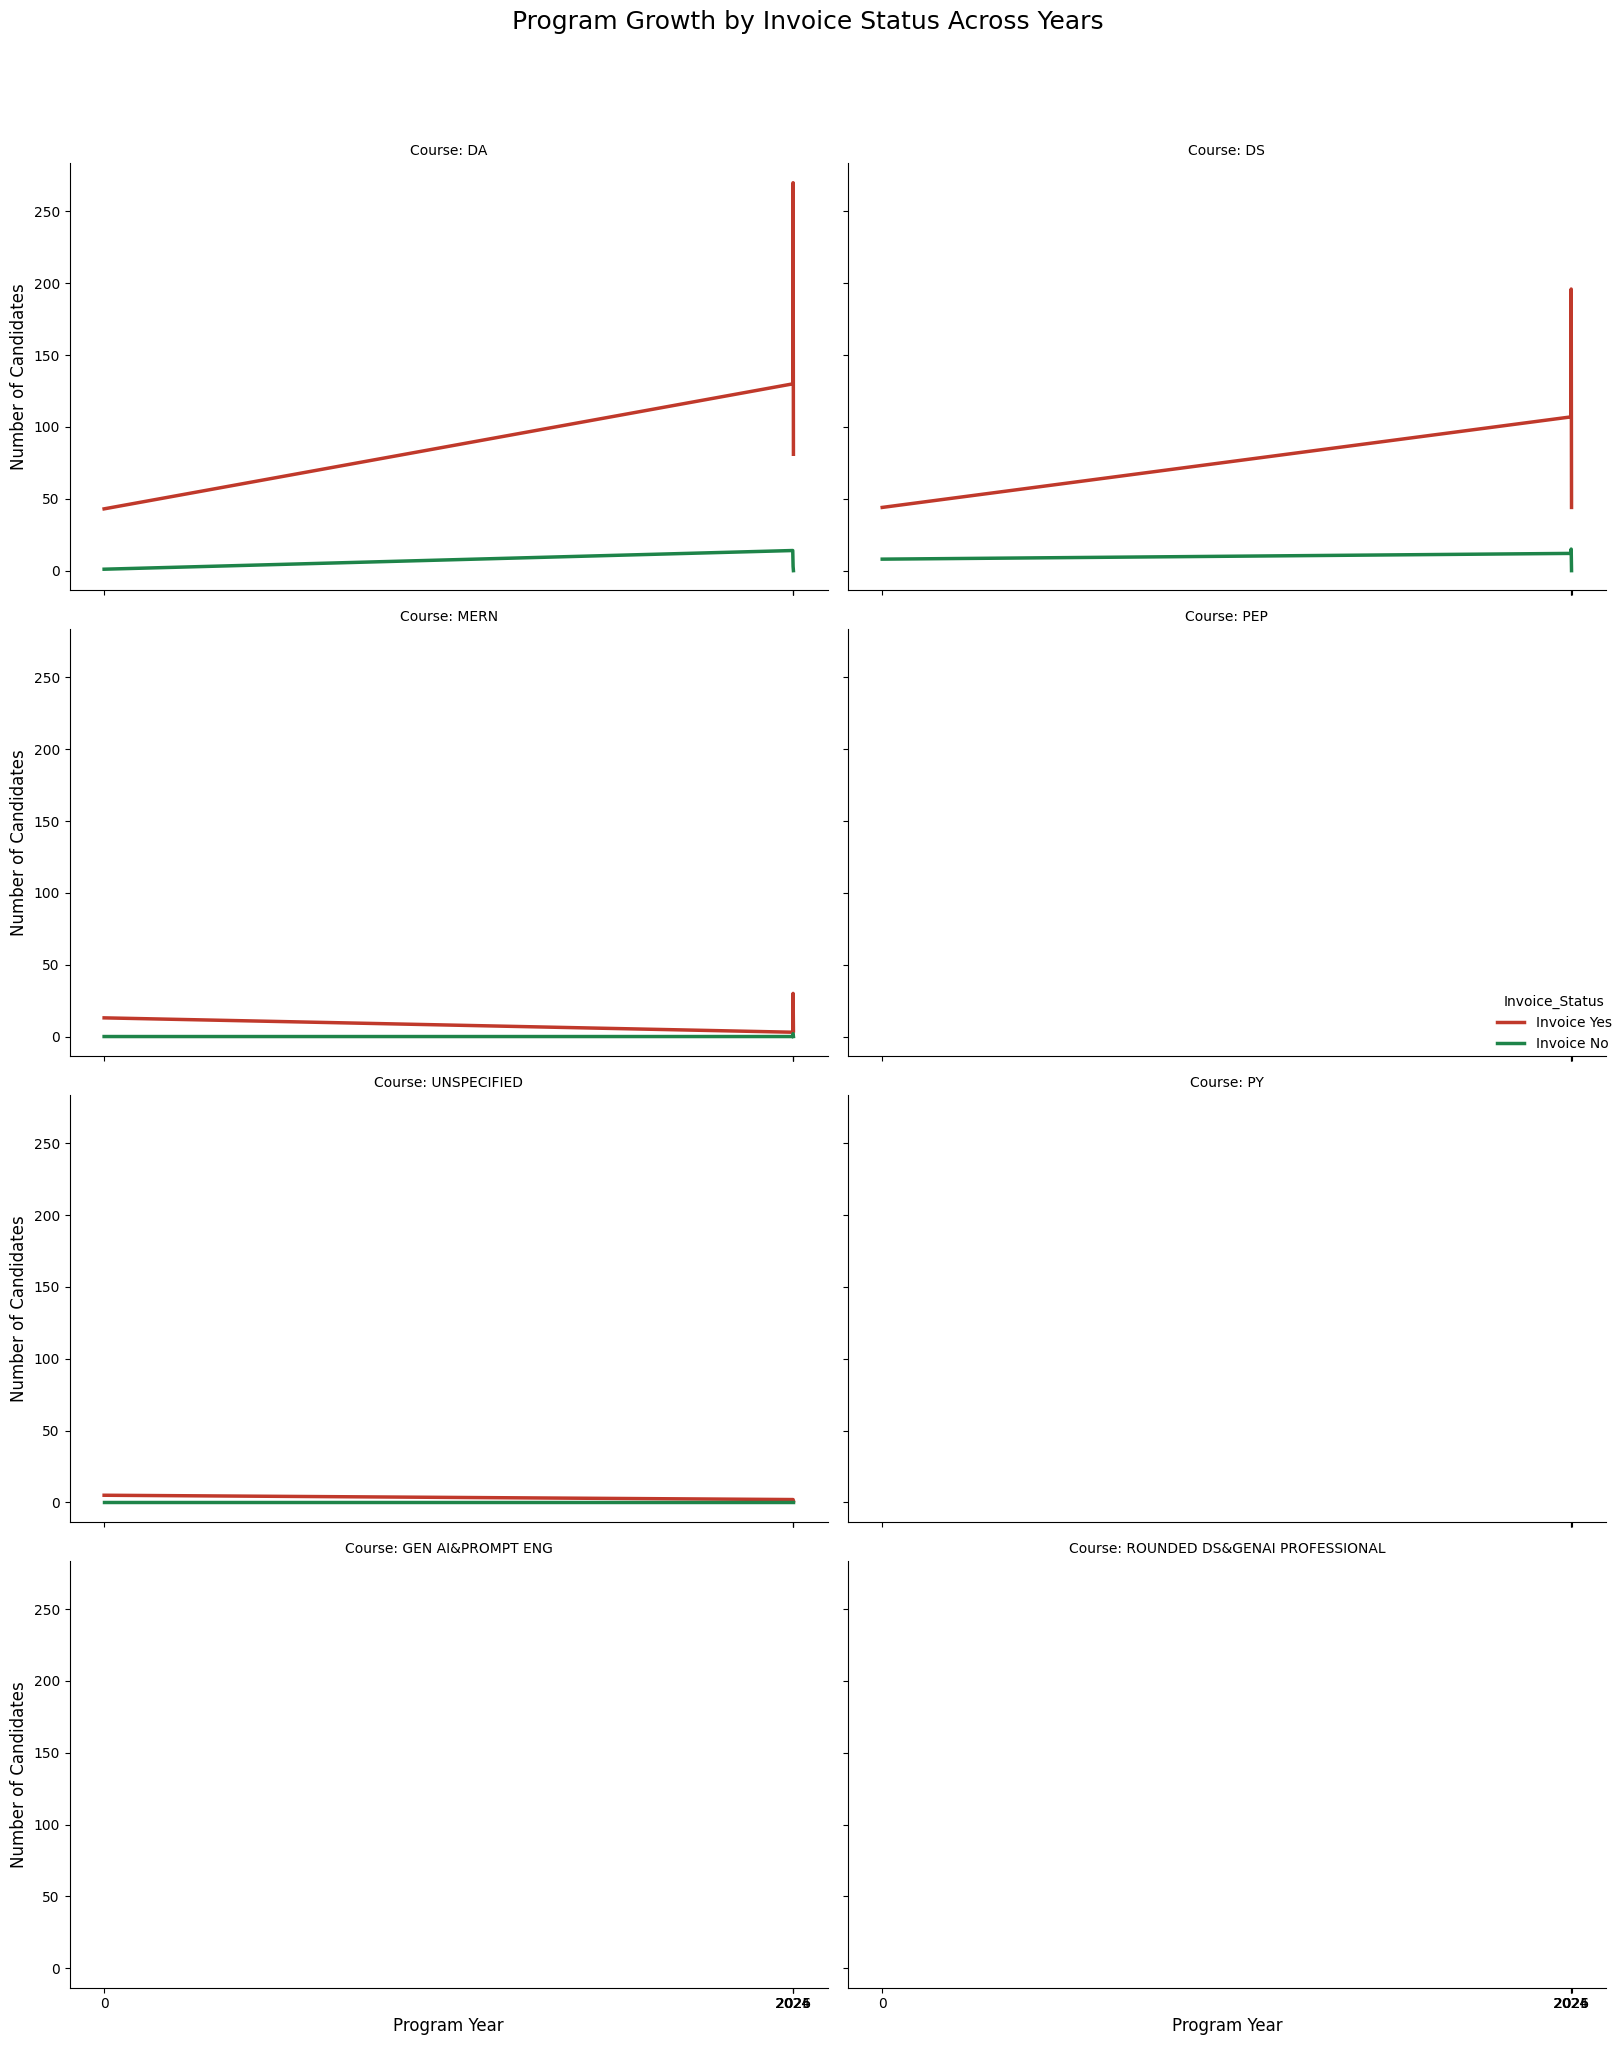

In [213]:
# Aggregate data by Program_Year, Course_Name, and Invoice status
program_year_invoice_counts = program_data_for_plot.groupby(['Program_Year', 'Program_Name', 'Invoice']).size().unstack(fill_value=0).reset_index()

# Rename columns for clarity in the plot
program_year_invoice_counts = program_year_invoice_counts.rename(columns={'Yes': 'Invoice_Yes_Count', 'No': 'Invoice_No_Count'})

# Melt the DataFrame to a long format suitable for line plotting with hue
plot_df_long = program_year_invoice_counts.melt(
    id_vars=['Program_Year', 'Program_Name'],
    value_vars=['Invoice_Yes_Count', 'Invoice_No_Count'],
    var_name='Invoice_Status_Raw',
    value_name='Count'
)

# Clean up Invoice_Status for better legend labels
plot_df_long['Invoice_Status'] = plot_df_long['Invoice_Status_Raw'].replace(
    {'Invoice_Yes_Count': 'Invoice Yes', 'Invoice_No_Count': 'Invoice No'}
)

# Create a faceted line plot with darker palette, thicker lines, and larger fonts
# Increased height and aspect for a larger plot size
g = sns.relplot(
    data=plot_df_long,
    x='Program_Year',
    y='Count',
    hue='Invoice_Status',
    col='Program_Name', # Facet by Course_Name to get one plot per program
    kind='line',
    col_wrap=2, # Wrap columns after 2 plots for even larger individual plot sizes
    height=5, aspect=1.5, # Adjusted for larger plot size
    palette={'Invoice Yes': '#C0392B', 'Invoice No': '#1E8449'}, # Darker, more distinct colors
    linewidth=2.5 # Make lines thicker
)

# Customize titles and labels with larger font sizes
g.set_axis_labels("Program Year", "Number of Candidates", fontsize=12)
g.set_titles("Course: {col_name}", fontsize=14)
g.fig.suptitle('Program Growth by Invoice Status Across Years', y=1.02, fontsize=18) # Increase super title font size

# Get unique years from the data to use as x-axis ticks
unique_program_years = sorted(plot_df_long['Program_Year'].unique())

# Set x-ticks for each subplot to display only whole years
for ax in g.axes.flat:
    ax.set_xticks(unique_program_years)
    ax.set_xticklabels([str(int(year)) for year in unique_program_years])

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle from overlapping
plt.show()

### **Distribution of Candidates by Role**

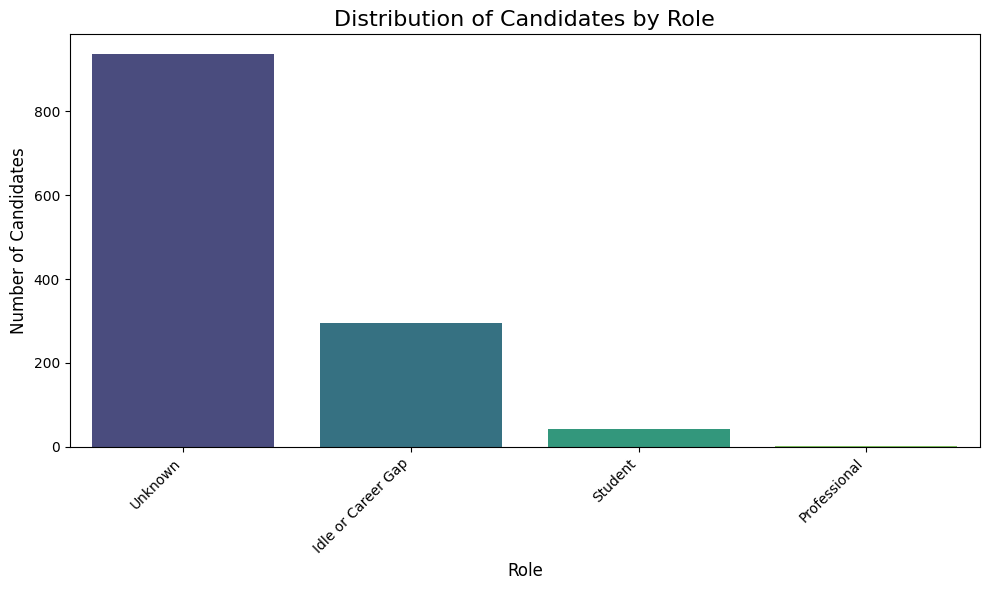

In [214]:
role_distribution = enrolled['role'].value_counts().reset_index()
role_distribution.columns = ['Role', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Role', y='Count', data=role_distribution, palette='viridis', hue='Role', legend=False)
plt.title('Distribution of Candidates by Role', fontsize=16)
plt.xlabel('Role', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Distribution of Candidates by Background (Tech/Non-Tech)**

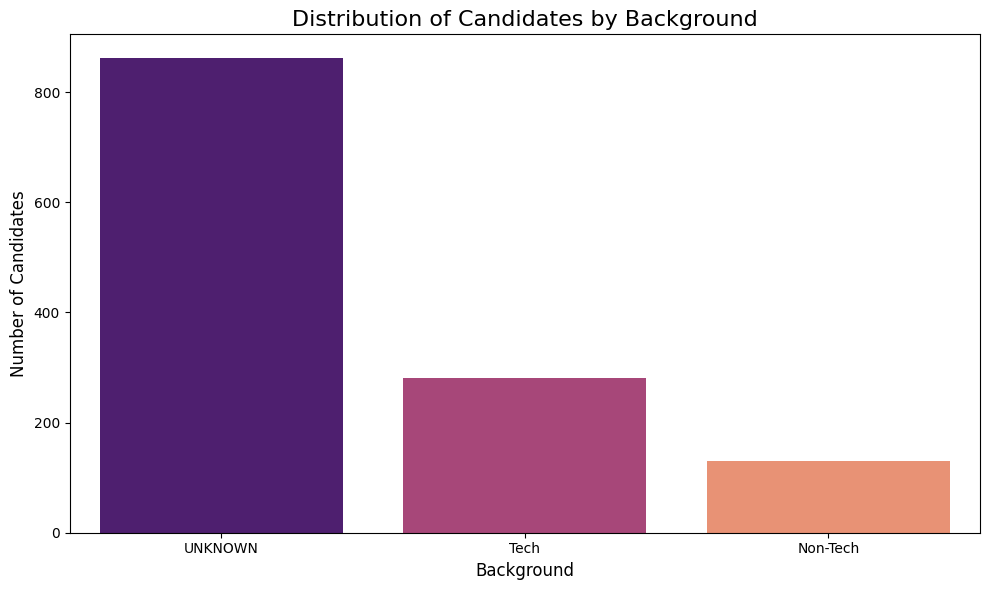

In [215]:
background_distribution = enrolled['background'].value_counts().reset_index()
background_distribution.columns = ['Background', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Background', y='Count', data=background_distribution, palette='magma', hue='Background', legend=False)
plt.title('Distribution of Candidates by Background', fontsize=16)
plt.xlabel('Background', fontsize=12)
plt.ylabel('Number of Candidates', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [216]:
print("\nTop Suggested Churn Reasons:")
print(inferred_reason_counts.head(10)) # Displaying the top 10 reasons


Top Suggested Churn Reasons:
                                           Reason  Count
0                       Unreachable/Not Connected   4100
1                     Decision Pending/Discussing    916
2                                  Not Interested    689
3      Looking for Job/Internship (Specific Type)    679
4                               Joined Competitor    570
5                      Already Working/Internship    395
6  Looking for Other Opportunity (Not Interested)    161
7                                 Financial Issue     45
8                          Time/Schedule Conflict     11
9                                  Location Issue      8


### **Churn by Candidate Source**

### **Active vs. Churned Candidates by Source of Lead**

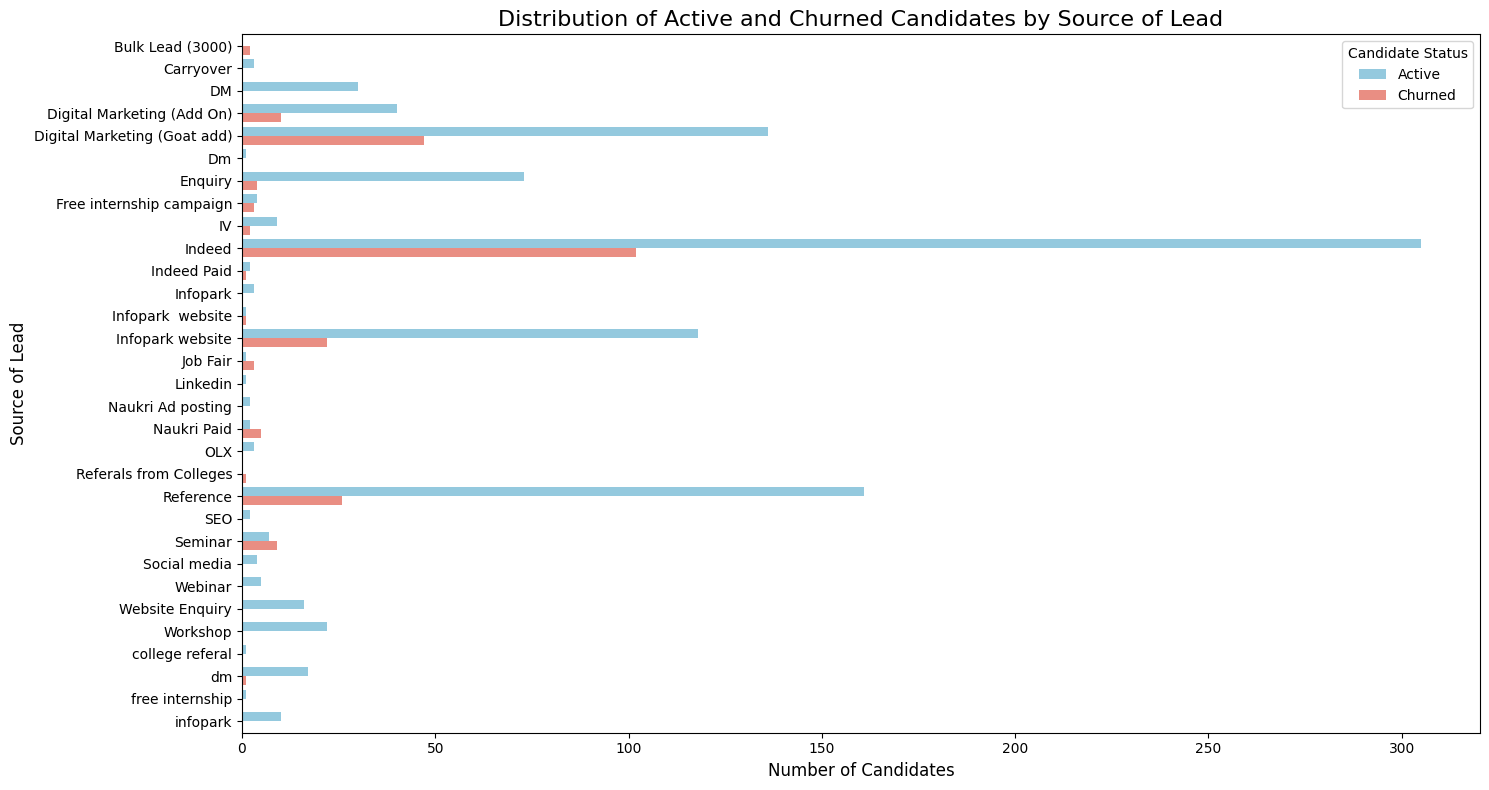

In [217]:
# Create a 'Status' column to differentiate between active and churned candidates
def get_status(row):
    if row['Program Joined'] != 'Not joined' and row['Invoice'] == 'Yes':
        return 'Active'
    elif row['Program Joined'] == 'Not joined': # Assuming all 'Not joined' are considered churned for this context
        return 'Churned'
    else:
        return 'Other/Not Classified' # Handle cases like 'Joined' but no invoice, if needed

enrolled['Status'] = enrolled.apply(get_status, axis=1)

# Filter for relevant statuses and group by source and status
churn_active_by_source = enrolled[enrolled['Status'].isin(['Active', 'Churned'])] \
                                .groupby(['Source of lead', 'Status']).size().unstack(fill_value=0).reset_index()

# Melt the DataFrame for easier plotting with seaborn
plot_df = churn_active_by_source.melt(id_vars='Source of lead', var_name='Status', value_name='Count')

plt.figure(figsize=(15, 8))
sns.barplot(x='Count', y='Source of lead', hue='Status', data=plot_df,
            palette={'Active': 'skyblue', 'Churned': 'salmon'})
plt.title('Distribution of Active and Churned Candidates by Source of Lead', fontsize=16)
plt.xlabel('Number of Candidates', fontsize=12)
plt.ylabel('Source of Lead', fontsize=12)
plt.legend(title='Candidate Status')
plt.tight_layout()
plt.show()

### **Training Mode of Churned and Active Candidates**

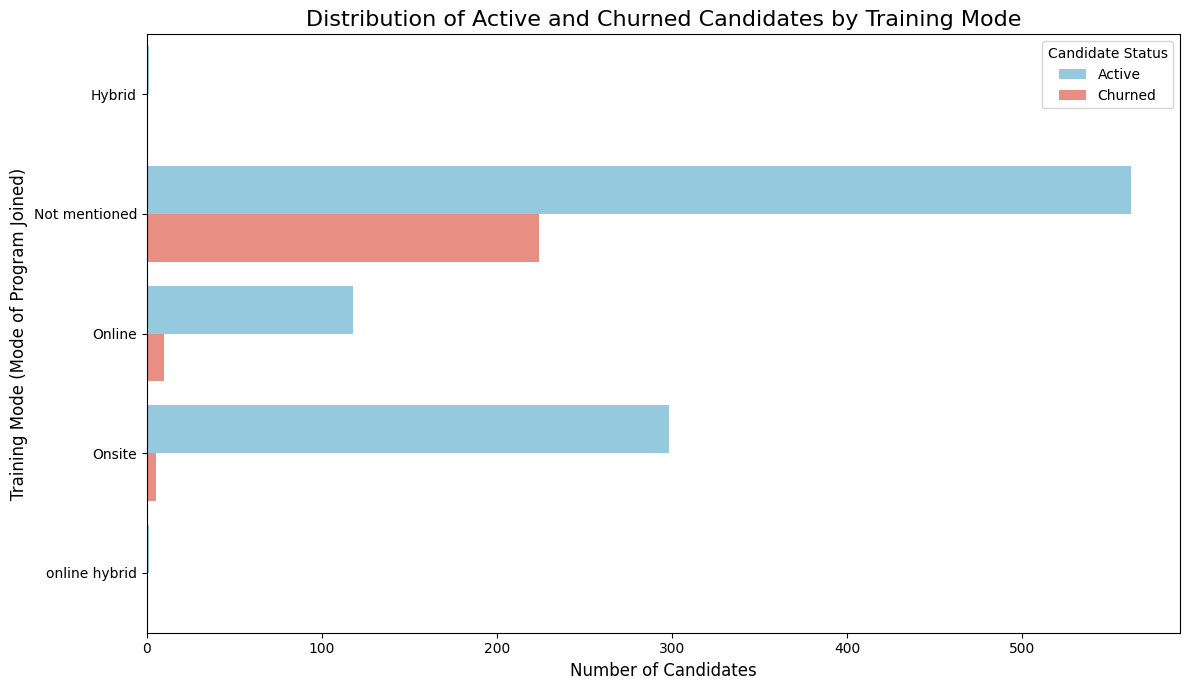

In [218]:
# Filter for active and churned candidates
active_churned_candidates = enrolled[enrolled['Status'].isin(['Active', 'Churned'])]

# Group by 'Mode of Program Joined' and 'Status'
churn_active_by_mode = active_churned_candidates.groupby(['Mode of Program Joined', 'Status']).size().unstack(fill_value=0).reset_index()

# Melt the DataFrame for easier plotting with seaborn
plot_df_mode = churn_active_by_mode.melt(id_vars='Mode of Program Joined', var_name='Status', value_name='Count')

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Mode of Program Joined', hue='Status', data=plot_df_mode,
            palette={'Active': 'skyblue', 'Churned': 'salmon'})
plt.title('Distribution of Active and Churned Candidates by Training Mode', fontsize=16)
plt.xlabel('Number of Candidates', fontsize=12)
plt.ylabel('Training Mode (Mode of Program Joined)', fontsize=12)
plt.legend(title='Candidate Status')
plt.tight_layout()
plt.show()

In [219]:
# Removing irrelevant columns for churn prediction
columns_to_drop = [
    'First Name',
    'Last Name',
    'Email Opt Out',
    'college Name.id',
    'college Name',
    'Unsubscribed Mode',
    'Unsubscribed Time',
    'City',
    'Mailing State',
    'Mailing Zip',
    'Mailing Country',
    'Whatsapp Number',
    'Region'
]

enrolled = enrolled.drop(columns=columns_to_drop)

print(f"Shape of enrolled DataFrame after dropping columns: {enrolled.shape}")
print(enrolled.head())

Shape of enrolled DataFrame after dropping columns: (1274, 34)
                Contact Id         Contact Owner.id  Contact Owner  \
0  zcrm_560042000000440092  zcrm_560042000000283001  SalesPerson-2   
1  zcrm_560042000000466061  zcrm_560042000000283001  SalesPerson-2   
2  zcrm_560042000000565094  zcrm_560042000000331113  SalesPerson-9   
3  zcrm_560042000000583691  zcrm_560042000000331113  SalesPerson-9   
4  zcrm_560042000000604837  zcrm_560042000000283001  SalesPerson-2   

    Track Interested            Tag    Description            Created By.id  \
0  Python Full stack  Not mentioned  Not mentioned  zcrm_560042000000283001   
1        Datascience  Not mentioned  Not mentioned  zcrm_560042000000283001   
2         Not joined  Not mentioned  Not mentioned  zcrm_560042000000331113   
3         Not joined         Ayisha  Not mentioned  zcrm_560042000000331113   
4                 DA       Enrolled  Not mentioned  zcrm_560042000000283001   

            Modified By.id        Created

#### **Merging enrolled and notes data sets for further analysis**



In [220]:
enrolled_with_notes = pd.merge(enrolled, notes, left_on='Contact Id', right_on='Parent ID.id', how='left', suffixes=('_enrolled', '_note'))

# Now apply the inference function using the correct 'sentences' column.
# Handle NaN values explicitly: if 'sentences' entry is NaN (due to left merge), treat it as 'No Notes Provided'.
enrolled_with_notes[['inferred_status_notes', 'inferred_reason_notes']] = \
    enrolled_with_notes['sentences'].apply(
        lambda x: pd.Series(infer_status_and_reason_from_notes(x))
        if isinstance(x, list) else pd.Series(['Unclear', 'No Notes Provided'])
    )

print(enrolled_with_notes[['Contact Id', 'Note Content', 'Program Joined', 'inferred_status_notes', 'inferred_reason_notes']].head())

                Contact Id                             Note Content  \
0  zcrm_560042000000440092                                      NaN   
1  zcrm_560042000000466061                                      NaN   
2  zcrm_560042000000565094                                      NaN   
3  zcrm_560042000000583691  He is interested , will be joining soon   
4  zcrm_560042000000604837                                      NaN   

         Program Joined inferred_status_notes inferred_reason_notes  
0            Not joined               Unclear     No Notes Provided  
1           DA May 2024               Unclear     No Notes Provided  
2            Not joined               Unclear     No Notes Provided  
3            Not joined            Join Later                   N/A  
4  DA Enrollee Sep 2024               Unclear     No Notes Provided  


In [221]:
def aggregate_inferred_status_reason(df_merged):
    # Group by 'Contact Id' and aggregate inferred statuses and reasons
    grouped = df_merged.groupby('Contact Id').agg(
        inferred_statuses=pd.NamedAgg(column='inferred_status_notes', aggfunc=lambda x: list(x.dropna().unique())),
        inferred_reasons=pd.NamedAgg(column='inferred_reason_notes', aggfunc=lambda x: list(x.dropna().unique()))
    ).reset_index()

    final_results = []
    for index, row in grouped.iterrows():
        contact_id = row['Contact Id']
        statuses = row['inferred_statuses']
        reasons = row['inferred_reasons']

        final_status = 'Unclear'
        final_reason = 'Other/Unspecified'

        # Define status precedence
        status_priority = {'Not Joined': 3, 'Join Later': 2, 'Joined': 1, 'Unclear': 4}
        # Filter out 'No Notes Provided' from reasons if it's the only one, or if other specific reasons exist
        filtered_reasons = [r for r in reasons if r not in ['No Notes Provided', 'N/A', 'Other/Unspecified', 'Interested/Pending', 'Details Shared/Collected (Candidate)']]

        # Determine final status based on priority
        current_priority = 0
        for s in statuses:
            if status_priority.get(s, 0) > current_priority:
                final_status = s
                current_priority = status_priority[s]

        # Determine final reason based on the final_status
        if final_status == 'Not Joined':
            # Collect all specific 'Not Joined' reasons
            not_joined_specific_reasons = [r for r in filtered_reasons if r in [
                'Joined Competitor', 'Already Working/Internship', 'Looking for Job/Internship (Specific Type)',
                'Not Interested', 'Financial Issue', 'Unreachable/Not Connected',
                'Decision Pending/Discussing', 'Location Issue', 'Time/Schedule Conflict'
            ]]
            if not_joined_specific_reasons:
                final_reason = ', '.join(sorted(list(set(not_joined_specific_reasons))))
            else:
                # If 'Not Joined' status is inferred but no specific reason, check for generic ones.
                if 'Unspecified Not Joined Reason' in reasons:
                    final_reason = 'Unspecified Not Joined Reason'
                elif 'Other/Unspecified' in reasons:
                    final_reason = 'Other/Unspecified'
                elif 'No Notes Provided' in reasons and len(filtered_reasons) == 0:
                    final_reason = 'No Notes Provided'
                else:
                    final_reason = 'Unspecified Not Joined Reason'
        elif final_status == 'Join Later':
            join_later_specific_reasons = [r for r in filtered_reasons if r == 'Unspecified Join Later Reason'] # 'N/A' is the common reason for 'Join Later' so filtered_reasons is important
            if join_later_specific_reasons:
                final_reason = ', '.join(sorted(list(set(join_later_specific_reasons))))
            else:
                final_reason = 'N/A' # Typically no specific reasons, just the status
        elif final_status == 'Joined':
            final_reason = 'N/A' # Typically no specific reasons for joining
        elif final_status == 'Unclear':
            unclear_specific_reasons = [r for r in filtered_reasons if r in ['Interested/Pending', 'Details Shared/Collected (Candidate)']]
            if unclear_specific_reasons:
                final_reason = ', '.join(sorted(list(set(unclear_specific_reasons))))
            elif 'No Notes Provided' in reasons and len(filtered_reasons) == 0:
                final_reason = 'No Notes Provided'
            else:
                final_reason = 'Other/Unspecified'

        final_results.append({
            'Contact Id': contact_id,
            'final_inferred_status': final_status,
            'final_inferred_reason': final_reason
        })

    return pd.DataFrame(final_results)

# Apply the aggregation function
aggregated_inferences = aggregate_inferred_status_reason(enrolled_with_notes)

# Drop existing 'final_inferred_status' and 'final_inferred_reason' columns from 'enrolled'
# and any _x suffixed versions if they exist, to avoid merge conflicts from re-running the cell.
for col_name in ['final_inferred_status', 'final_inferred_reason']:
    if col_name in enrolled.columns:
        enrolled = enrolled.drop(columns=[col_name])
    if f'{col_name}_x' in enrolled.columns: # Also drop _x suffixed versions
        enrolled = enrolled.drop(columns=[f'{col_name}_x'])
    if f'{col_name}_y' in enrolled.columns: # Also drop _y suffixed versions
        enrolled = enrolled.drop(columns=[f'{col_name}_y'])

# Merge these aggregated inferences back into the original 'enrolled' DataFrame
enrolled = pd.merge(enrolled, aggregated_inferences, on='Contact Id', how='left')

print("Enrolled DataFrame after merging with aggregated inferred status and reason:")
print(enrolled[['Contact Id', 'Program Joined', 'final_inferred_status', 'final_inferred_reason']].head())

print("\nDistribution of Final Inferred Status:")
print(enrolled['final_inferred_status'].value_counts())

print("\nDistribution of Final Inferred Reason:")
print(enrolled['final_inferred_reason'].value_counts())

Enrolled DataFrame after merging with aggregated inferred status and reason:
                Contact Id        Program Joined final_inferred_status  \
0  zcrm_560042000000440092            Not joined               Unclear   
1  zcrm_560042000000466061           DA May 2024               Unclear   
2  zcrm_560042000000565094            Not joined               Unclear   
3  zcrm_560042000000583691            Not joined            Join Later   
4  zcrm_560042000000604837  DA Enrollee Sep 2024               Unclear   

  final_inferred_reason  
0     No Notes Provided  
1     No Notes Provided  
2     No Notes Provided  
3                   N/A  
4     No Notes Provided  

Distribution of Final Inferred Status:
final_inferred_status
Unclear       1087
Not Joined     159
Joined          23
Join Later       5
Name: count, dtype: int64

Distribution of Final Inferred Reason:
final_inferred_reason
No Notes Provided                                        932
Other/Unspecified                  

### **Distribution of Final Inferred Status**

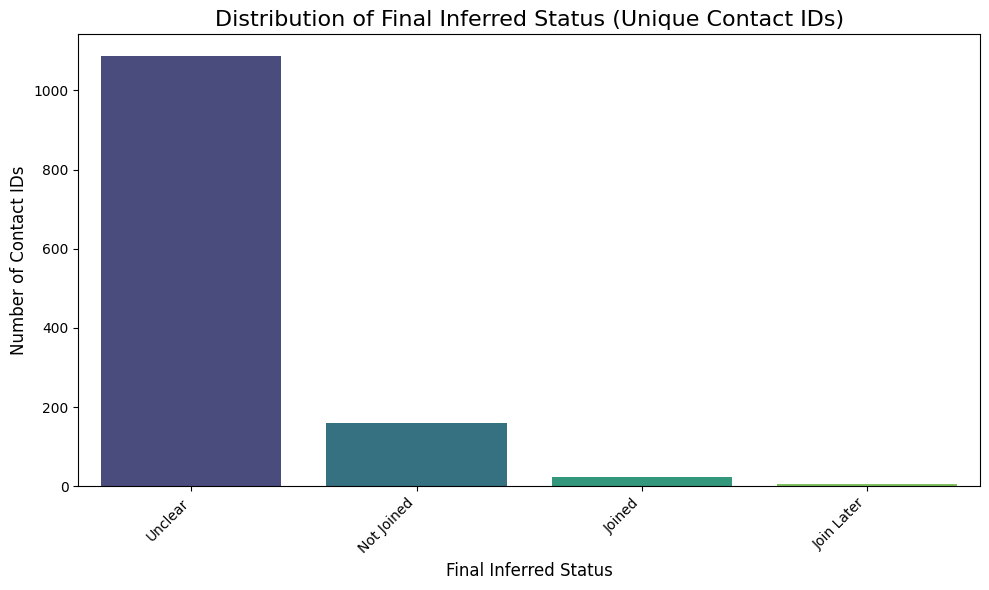

In [222]:
final_status_counts = enrolled['final_inferred_status'].value_counts().reset_index()
final_status_counts.columns = ['Status', 'Count']

plt.figure(figsize=(10, 6))
sns.barplot(x='Status', y='Count', data=final_status_counts, palette='viridis', hue='Status', legend=False)
plt.title('Distribution of Final Inferred Status (Unique Contact IDs)', fontsize=16)
plt.xlabel('Final Inferred Status', fontsize=12)
plt.ylabel('Number of Contact IDs', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Distribution of Final Inferred Reason**

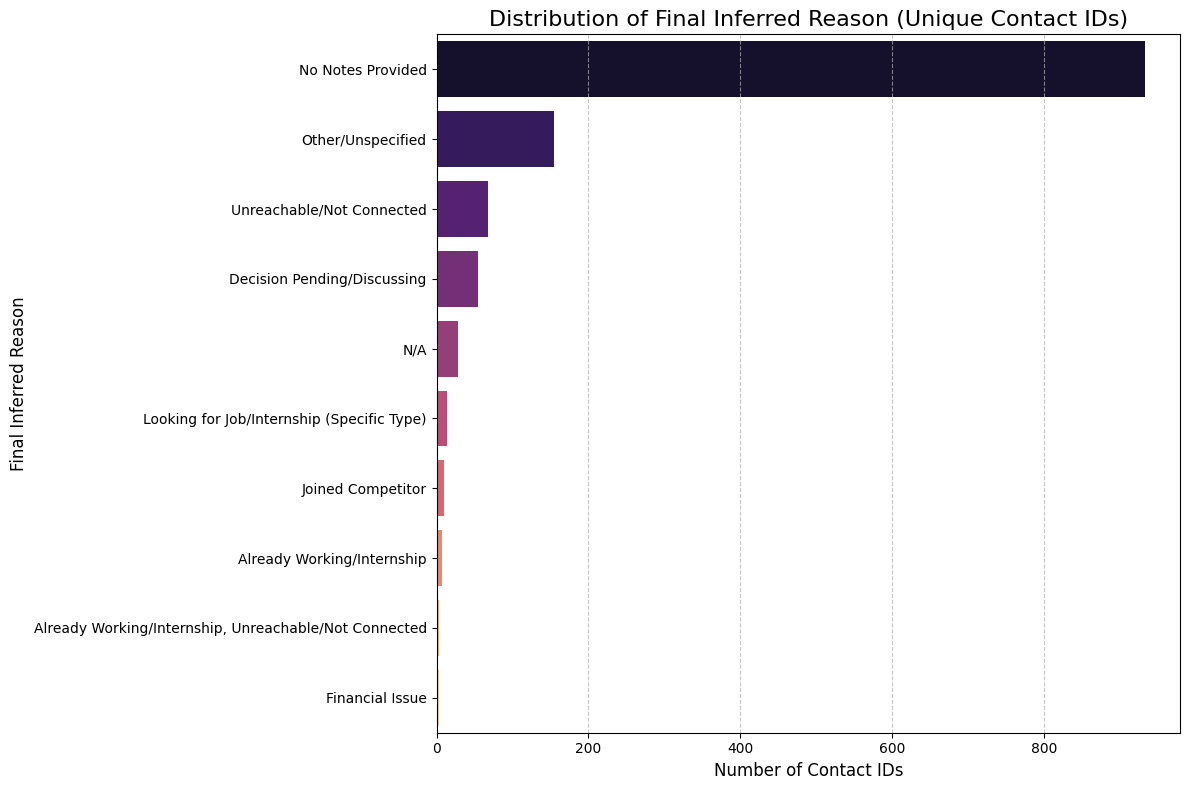

In [223]:
final_reason_counts = enrolled['final_inferred_reason'].value_counts().reset_index()
final_reason_counts.columns = ['Reason', 'Count']

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Reason', data=final_reason_counts, palette='magma', hue='Reason', legend=False)
plt.title('Distribution of Final Inferred Reason (Unique Contact IDs)', fontsize=16)
plt.xlabel('Number of Contact IDs', fontsize=12)
plt.ylabel('Final Inferred Reason', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Churn Prediction Model**


STEP: FEATURE IMPORTANCE ANALYSIS

Top 10 Feature Importances (Absolute Coefficients) for SVM:

                                Feature  Importance
       cat__Track Interested_Not joined    2.081106
cat__Track Interested_Python Full stack    2.000017
                      cat__role_Student    0.321902
                      cat__role_Unknown    0.222094
         continuous__Year of Graduation    0.120353
               cat__Track Interested_DS    0.080964
           cat__Source of lead_Workshop    0.067056
                     cat__Course_MSC-IT    0.063691
                   continuous__Semester    0.034562
                        cat__Course_MCA    0.016949

  Feature importance report saved to: feature_importance_report.csv


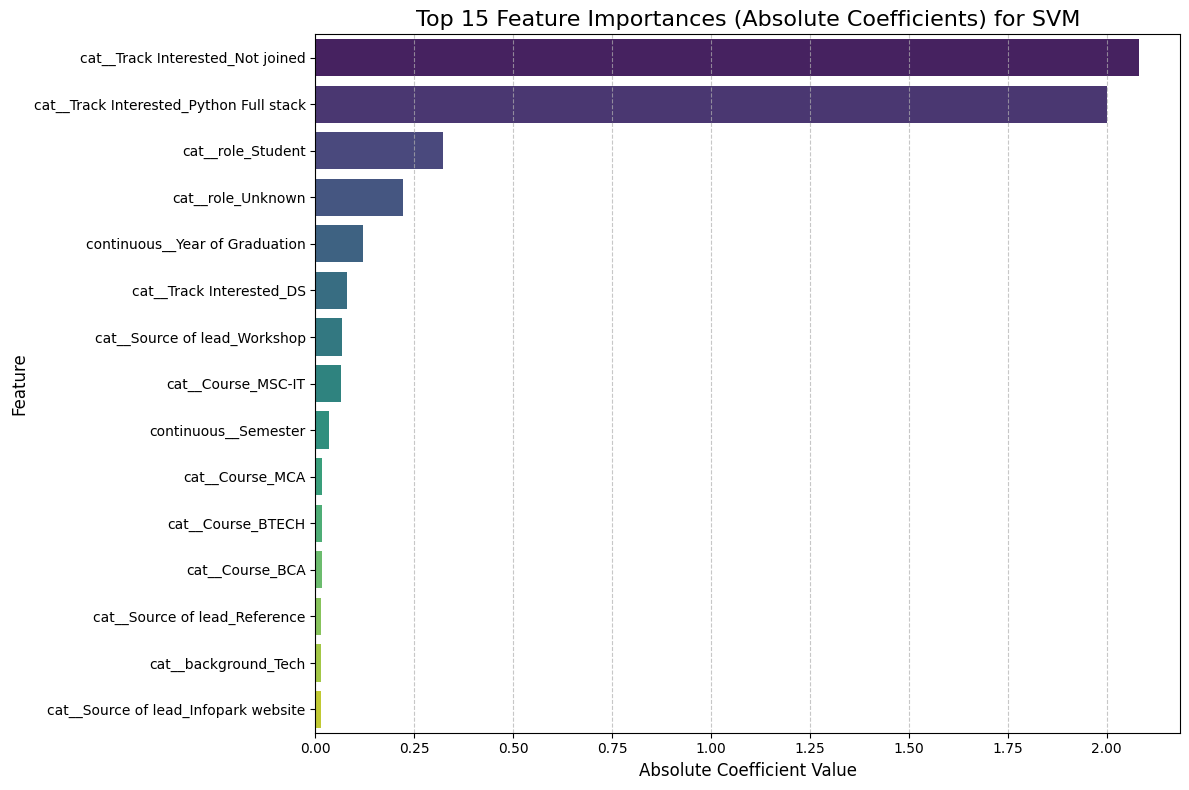

  Feature importance chart saved to: feature_importance.png


In [224]:
print('\n' + '='*80)
print('STEP: FEATURE IMPORTANCE ANALYSIS')
print('='*80)

# Assuming final_model is already selected and fitted
# Check if the final model has feature_importances_ attribute (e.g., Tree-based models)
if hasattr(final_model, 'feature_importances_'):
    # Create a DataFrame for feature importances
    feature_importance_df = pd.DataFrame({
        'Feature': X_train_processed.columns,
        'Importance': final_model.feature_importances_
    })

    # Sort by importance in descending order
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print('\nTop 10 Feature Importances for ' + final_model_name + ':\n')
    print(feature_importance_df.head(10).to_string(index=False))

    # Save feature importance to a CSV file
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_report.csv'), index=False)
    print("\n  Feature importance report saved to: feature_importance_report.csv")

    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis', hue='Feature', legend=False)
    plt.title(f'Top 15 Feature Importances for {final_model_name}', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'feature_importance.png'))
    plt.show()
    print("  Feature importance chart saved to: feature_importance.png")
elif hasattr(final_model, 'coef_'): # For linear models like Logistic Regression
    # Assuming binary classification, get coefficients for class 1
    coefficients = final_model.coef_[0]
    feature_importance_df = pd.DataFrame({
        'Feature': X_train_processed.columns,
        'Importance': np.abs(coefficients) # Use absolute value for importance
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print('\nTop 10 Feature Importances (Absolute Coefficients) for ' + final_model_name + ':\n')
    print(feature_importance_df.head(10).to_string(index=False))

    # Save feature importance to a CSV file
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_report.csv'), index=False)
    print("\n  Feature importance report saved to: feature_importance_report.csv")

    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis', hue='Feature', legend=False)
    plt.title(f'Top 15 Feature Importances (Absolute Coefficients) for {final_model_name}', fontsize=16)
    plt.xlabel('Absolute Coefficient Value', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'feature_importance.png'))
    plt.show()
    print("  Feature importance chart saved to: feature_importance.png")
else:
    print(f"Feature importance extraction not supported for {final_model_name} (model type: {type(final_model).__name__}).")


### **Target Variable Creation**



In [225]:
# Define conditions for churn
conditions = [
    (enrolled['Program Joined'] != 'Not joined') & (enrolled['Invoice'] == 'Yes'), # Non-churned (Active with Invoice)
    (enrolled['Program Joined'] == 'Not joined') & (enrolled['Invoice'] == 'Yes'), # Churned with Invoice
    (enrolled['Invoice'] == 'No') # Candidates without an invoice, or where invoice status is not 'Yes'
]

# Define choices for churn (0 for non-churn, 1 for churn, -1 for other cases)
choices = [0, 1, -1]

enrolled['churn'] = np.select(conditions, choices, default=-1) # Use -1 to denote cases not explicitly 0 or 1

print("Distribution of Churn Target Variable (0=Non-churned, 1=Churned, -1=Not classified by explicit invoice criteria):")
print(enrolled['churn'].value_counts())


Distribution of Churn Target Variable (0=Non-churned, 1=Churned, -1=Not classified by explicit invoice criteria):
churn
 0    980
-1    190
 1    104
Name: count, dtype: int64


In [226]:
enrolled.to_csv(os.path.join(ARTIFACTS_PATH, 'enrolled_processed.csv'), index=False)
notes.to_csv(os.path.join(ARTIFACTS_PATH, 'notes_processed.csv'), index=False)
print(f"Processed 'enrolled' and 'notes' DataFrames saved to {ARTIFACTS_PATH}")

Processed 'enrolled' and 'notes' DataFrames saved to ./output


### Create Filtered DataFrame for Model



In [227]:
enrolled_for_model = enrolled[enrolled['churn'].isin([0, 1])].copy()

print("Shape of enrolled_for_model:", enrolled_for_model.shape)
print("First 5 rows of enrolled_for_model:")
print(enrolled_for_model.head())
print("\nDistribution of 'churn' in enrolled_for_model:")
print(enrolled_for_model['churn'].value_counts())

Shape of enrolled_for_model: (1084, 37)
First 5 rows of enrolled_for_model:
                Contact Id         Contact Owner.id  Contact Owner  \
0  zcrm_560042000000440092  zcrm_560042000000283001  SalesPerson-2   
2  zcrm_560042000000565094  zcrm_560042000000331113  SalesPerson-9   
3  zcrm_560042000000583691  zcrm_560042000000331113  SalesPerson-9   
4  zcrm_560042000000604837  zcrm_560042000000283001  SalesPerson-2   
5  zcrm_560042000000604840  zcrm_560042000000283001  SalesPerson-2   

    Track Interested            Tag    Description            Created By.id  \
0  Python Full stack  Not mentioned  Not mentioned  zcrm_560042000000283001   
2         Not joined  Not mentioned  Not mentioned  zcrm_560042000000331113   
3         Not joined         Ayisha  Not mentioned  zcrm_560042000000331113   
4                 DA       Enrolled  Not mentioned  zcrm_560042000000283001   
5                 DA       Enrolled  Not mentioned  zcrm_560042000000283001   

            Modified By.id  

In [228]:
enrolled.to_csv(os.path.join(ARTIFACTS_PATH, 'enrolled_processed.csv'), index=False)
notes.to_csv(os.path.join(ARTIFACTS_PATH, 'notes_processed.csv'), index=False)
print(f"Processed 'enrolled' and 'notes' DataFrames saved to {ARTIFACTS_PATH}")


Processed 'enrolled' and 'notes' DataFrames saved to ./output


###  **Feature Engineering**



In [229]:
# Convert boolean columns to int for consistency with other numerical features
enrolled_for_model['Test'] = enrolled_for_model['Test'].astype(int)
enrolled_for_model['Followup Email'] = enrolled_for_model['Followup Email'].astype(int)
enrolled_for_model['Invoice_binary'] = enrolled_for_model['Invoice'].apply(lambda x: 1 if x == 'Yes' else 0)

print("Derived binary features and converted boolean columns added to `enrolled_for_model`.")
# Display new columns and a few existing ones to verify
print(enrolled_for_model[['Contact Id', 'Test', 'Followup Email', 'Invoice', 'Invoice_binary']].head())

Derived binary features and converted boolean columns added to `enrolled_for_model`.
                Contact Id  Test  Followup Email Invoice  Invoice_binary
0  zcrm_560042000000440092     0               0     Yes               1
2  zcrm_560042000000565094     0               0     Yes               1
3  zcrm_560042000000583691     0               0     Yes               1
4  zcrm_560042000000604837     0               1     Yes               1
5  zcrm_560042000000604840     0               1     Yes               1


### **Feature Selection for Modeling**



In [230]:
print("\n Selecting Features for Modeling...")

# Define feature categories based on available data
categorical_features_doc = [
    'Source of lead',
    'Course',
    'background',
    'role',
    'Track Interested',
    'Mode of Program Joined',
   'Gender'
]

numerical_features_doc = [
    'Experience',
    'Semester',
    'Year of Graduation'
]

binary_features_doc = [
    'Test',
    'Followup Email'
]

# Filter to only existing columns in enrolled_for_model
categorical_features = [col for col in categorical_features_doc if col in enrolled_for_model.columns]
numerical_features = [col for col in numerical_features_doc if col in enrolled_for_model.columns]
binary_features = [col for col in binary_features_doc if col in enrolled_for_model.columns]

print(f"   Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"   Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"   Binary features ({len(binary_features)}): {binary_features}")

# Combine all selected features
all_features = numerical_features + categorical_features + binary_features
X = enrolled_for_model[all_features].copy()
y = enrolled_for_model['churn'].copy()

print("\nShape of features (X) after one-hot encoding and feature selection:", X.shape)
print("Head of processed features (X):")
print(X.head())


 Selecting Features for Modeling...
   Categorical features (7): ['Source of lead', 'Course', 'background', 'role', 'Track Interested', 'Mode of Program Joined', 'Gender']
   Numerical features (3): ['Experience', 'Semester', 'Year of Graduation']
   Binary features (2): ['Test', 'Followup Email']

Shape of features (X) after one-hot encoding and feature selection: (1084, 12)
Head of processed features (X):
   Experience  Semester  Year of Graduation Source of lead  Course background  \
0           0         0                   0         Indeed   BTECH       Tech   
2           0         0                2023      Reference     BCA       Tech   
3           0         0                2023      Reference     BCA       Tech   
4           0         4                2024      Reference  MSC-IT       Tech   
5           0         4                2024      Reference  MSC-IT       Tech   

                 role   Track Interested Mode of Program Joined Gender  Test  \
0             Unknown

### **Data spliting**



In [231]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (867, 12)
Shape of X_test: (217, 12)
Shape of y_train: (867,)
Shape of y_test: (217,)


### **Encoding and Feature Scaling**




In [232]:
# Build ONE preprocessor that handles everything
preprocessor = ColumnTransformer(
    transformers=[
        ('continuous', StandardScaler(), numerical_features),  # Scale
        ('binary', 'passthrough', binary_features),             # Leave as 0/1
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features)                                  # Encode
    ]
)
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
# Transform the test data
X_test_processed  = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
# For simplicity, let's assume get_feature_names_out is available or construct manually.
# This part needs to be robust for different sklearn versions and types of transformers.
feature_names_out = preprocessor.get_feature_names_out()

# Convert sparse matrices to DataFrames
X_train_processed = pd.DataFrame(X_train_processed.toarray(), columns=feature_names_out, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed.toarray(), columns=feature_names_out, index=X_test.index)

print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")
print("Head of X_train_processed:")
print(X_train_processed.head())

Shape of X_train_processed: (867, 91)
Shape of X_test_processed: (217, 91)
Head of X_train_processed:
     continuous__Experience  continuous__Semester  \
825                     0.0             -0.143289   
259                     0.0             -0.143289   
263                     0.0             -0.143289   
371                     0.0             -0.143289   
450                     0.0             -0.143289   

     continuous__Year of Graduation  binary__Test  binary__Followup Email  \
825                       -0.468623           0.0                     0.0   
259                        1.379902           0.0                     0.0   
263                       -0.468623           0.0                     0.0   
371                       -0.468623           0.0                     0.0   
450                       -0.468623           0.0                     0.0   

     cat__Source of lead_DM  cat__Source of lead_Digital Marketing (Add On)  \
825                     0.0          

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [233]:
# Define feature_columns using the names generated by the preprocessor
feature_columns = feature_names_out.tolist()
print(f"Defined {len(feature_columns)} feature columns.")
# You might want to remove transformer prefixes for cleaner display if needed
clean_feature_columns = [re.sub(r'^(continuous__|binary__|cat__)', '', col) for col in feature_columns]
print("First 10 clean feature names:", clean_feature_columns[:10])

Defined 91 feature columns.
First 10 clean feature names: ['Experience', 'Semester', 'Year of Graduation', 'Test', 'Followup Email', 'Source of lead_DM', 'Source of lead_Digital Marketing (Add On)', 'Source of lead_Digital Marketing (Goat add)', 'Source of lead_Enquiry', 'Source of lead_Free internship campaign']


### **Imbalance Analysis**



In [234]:
print("Distribution of Churn in Training Set (before balancing):")
print(y_train.value_counts(normalize=True))

churn_rate_train = y_train.value_counts(normalize=True).get(1, 0) # Get churn rate for class 1
non_churn_rate_train = y_train.value_counts(normalize=True).get(0, 0) # Get non-churn rate for class 0

if churn_rate_train > 0:
    imbalance_ratio = non_churn_rate_train / churn_rate_train
    print(f"\nImbalance Ratio (Non-Churn:Churn) in Training Set: {imbalance_ratio:.2f}:1")
else:
    print("\nNo churn instances in the training set.")

Distribution of Churn in Training Set (before balancing):
churn
0    0.904268
1    0.095732
Name: proportion, dtype: float64

Imbalance Ratio (Non-Churn:Churn) in Training Set: 9.45:1


### Evaluate Balancing Techniques




In [235]:
def resample_train_set(X_train_df, y_train, method='none', random_state=42):
    X_resampled, y_resampled, sample_weights = X_train_df, y_train, None

    # Convert method to lowercase for consistent comparison
    method = method.lower()

    if method == 'oversample':
        oversampler = RandomOverSampler(random_state=random_state)
        X_resampled, y_resampled = oversampler.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] Oversample applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'undersample':
        undersampler = RandomUnderSampler(random_state=random_state)
        X_resampled, y_resampled = undersampler.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] Undersample applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'smote':
        smote = SMOTE(random_state=random_state)
        X_resampled, y_resampled = smote.fit_resample(X_train_df, y_train)
        print(f"[DEBUG] SMOTE applied. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")
    elif method == 'class_weight':
        # For class_weight, we don't resample X_train, but compute sample weights
        # We still use the original X_train, y_train for the model training step
        # The `compute_class_weight` function takes the original y_train.
        weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train), weights)}
        # Create sample_weights for each instance in the training set
        sample_weights = y_train.map(class_weights_dict).values
        X_resampled, y_resampled = X_train_df, y_train # No actual resampling of data
        print(f"[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: {X_resampled.shape}, y_resampled shape: {y_resampled.shape}")

    # Ensure X_resampled is a DataFrame with column names
    if not isinstance(X_resampled, pd.DataFrame):
        X_resampled = pd.DataFrame(X_resampled, columns=X_train_df.columns, index=y_resampled.index)

    return X_resampled, y_resampled, sample_weights

def evaluate_balancing_techniques(X_train_processed, y_train, techniques, random_state=42):
    results = {}
    for name, method in techniques.items():
        print(f"\nEvaluating: {name}")
        precisions, recalls, f1_scores = [], [], []

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

        # X_train_processed is now a DataFrame, so .iloc works.
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_processed, y_train)):
            X_fold_train, X_fold_val = X_train_processed.iloc[train_idx], X_train_processed.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            # Apply balancing technique. Pass DataFrame X_fold_train.
            X_resampled, y_resampled, sample_weights = resample_train_set(X_fold_train, y_fold_train, method=method, random_state=random_state)

            # Initialize Logistic Regression model
            # For 'class_weight' method, pass class_weight directly to the model if sample_weights is None
            if method == 'class_weight' and sample_weights is None:
                model = LogisticRegression(solver='liblinear', random_state=random_state, class_weight='balanced')
            else:
                model = LogisticRegression(solver='liblinear', random_state=random_state)

            # Train the model
            if sample_weights is not None and method == 'class_weight': # Only pass sample_weights if 'class_weight' method generated them
                # For 'class_weight' method, X_resampled, y_resampled are still original X_train, y_train
                model.fit(X_resampled, y_resampled, sample_weight=sample_weights)
            else:
                model.fit(X_resampled, y_resampled)

            y_pred = model.predict(X_fold_val)

            precisions.append(precision_score(y_fold_val, y_pred, zero_division=0))
            recalls.append(recall_score(y_fold_val, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_fold_val, y_pred, zero_division=0))

        results[name] = {
            'Precision': np.mean(precisions),
            'Recall': np.mean(recalls),
            'F1 Score': np.mean(f1_scores)
        }
    return pd.DataFrame(results).T

techniques = {
    'None': 'none',
    'Class Weight': 'class_weight',
    'Oversample': 'oversample',
    'Undersample': 'undersample',
    'SMOTE': 'smote'
}

evaluation_results = evaluate_balancing_techniques(X_train_processed, y_train, techniques)
print(evaluation_results)

# Select the best performing balance_method based on F1 Score
best_balance_method = evaluation_results['F1 Score'].idxmax()
print(f"\nBest balancing method based on F1 Score: {best_balance_method}")


Evaluating: None

Evaluating: Class Weight
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (693, 91), y_resampled shape: (693,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (693, 91), y_resampled shape: (693,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 91), y_resampled shape: (694,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 91), y_resampled shape: (694,)
[DEBUG] Class Weight applied. No resampling of data. X_resampled shape: (694, 91), y_resampled shape: (694,)

Evaluating: Oversample
[DEBUG] Oversample applied. X_resampled shape: (1254, 91), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 91), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 91), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled shape: (1254, 91), y_resampled shape: (1254,)
[DEBUG] Oversample applied. X_resampled sha

#### Applying best  balancing technique

In [236]:
X_train_fit, y_train_fit, sample_weights = resample_train_set(X_train_processed, y_train, method=best_balance_method)

print(f"Shape of X_train_fit after applying '{best_balance_method}': {X_train_fit.shape}")
print(f"Shape of y_train_fit after applying '{best_balance_method}': {y_train_fit.shape}")
print("\nDistribution of Churn in X_train_fit:")
print(y_train_fit.value_counts(normalize=True))

# 'sample_weights' will only be non-None if 'class_weight' was the chosen method
# Otherwise, it will be None, and models will not use it explicitly.
if sample_weights is not None:
    print("Sample weights have been generated for class_weight method.")
else:
    print("No explicit sample weights generated (resampling method was applied directly to data).")

# Assertion to ensure resampling occurred if method is 'oversample', 'undersample', or 'smote'
if best_balance_method.lower() in ['oversample', 'undersample', 'smote']:
    original_minority_count = y_train.value_counts()[1]
    original_majority_count = y_train.value_counts()[0]
    resampled_minority_count = y_train_fit.value_counts()[1]
    resampled_majority_count = y_train_fit.value_counts()[0]

    if best_balance_method.lower() == 'smote':
        # SMOTE aims to balance the classes so minority count should become equal to majority count
        assert resampled_minority_count == original_majority_count, f"SMOTE failed: Minority count mismatch. Expected {original_majority_count}, got {resampled_minority_count}"
        assert resampled_majority_count == original_majority_count, f"SMOTE failed: Majority count mismatch. Expected {original_majority_count}, got {resampled_majority_count}"
        print(f"\n[INFO] SMOTE resampling confirmed: Minority class count ({resampled_minority_count}) now equals majority class count ({original_majority_count}).")
    elif best_balance_method.lower() == 'oversample':
        # RandomOverSampler also balances to majority class count by default
        assert resampled_minority_count == original_majority_count, f"Oversample failed: Minority count mismatch. Expected {original_majority_count}, got {resampled_minority_count}"
        assert resampled_majority_count == original_majority_count, f"Oversample failed: Majority count mismatch. Expected {original_majority_count}, got {resampled_majority_count}"
        print(f"\n[INFO] Oversample resampling confirmed: Minority class count ({resampled_minority_count}) now equals majority class count ({original_majority_count}).")
    elif best_balance_method.lower() == 'undersample':
        # RandomUnderSampler reduces majority to minority class count by default
        assert resampled_majority_count == original_minority_count, f"Undersample failed: Majority count mismatch. Expected {original_minority_count}, got {resampled_majority_count}"
        assert resampled_minority_count == original_minority_count, f"Undersample failed: Minority count mismatch. Expected {original_minority_count}, got {resampled_minority_count}"
        print(f"\n[INFO] Undersample resampling confirmed: Majority class count ({resampled_majority_count}) now equals minority class count ({original_minority_count}).")

Shape of X_train_fit after applying 'None': (867, 91)
Shape of y_train_fit after applying 'None': (867,)

Distribution of Churn in X_train_fit:
churn
0    0.904268
1    0.095732
Name: proportion, dtype: float64
No explicit sample weights generated (resampling method was applied directly to data).


### **Model Training and Evaluation**




In [237]:
# Define the models with a fixed random_state for reproducibility
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(), # KNN does not have a random_state parameter
    'SVM': SVC(random_state=42, probability=True), # probability=True is needed for ROC-AUC
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Suppress warning for use_label_encoder
}

print("Defined the following models:")
for name, model in models.items():
    print(f"- {name}: {model.__class__.__name__}")

Defined the following models:
- Logistic Regression: LogisticRegression
- Decision Tree: DecisionTreeClassifier
- Random Forest: RandomForestClassifier
- Gradient Boosting: GradientBoostingClassifier
- AdaBoost: AdaBoostClassifier
- K-Nearest Neighbors: KNeighborsClassifier
- SVM: SVC
- XGBoost: XGBClassifier


#### Evaluate Models




In [238]:
model_performance = {}

print("Starting model training and evaluation...")
for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")
    start_time = time.time()

    # Train the model
    # Use sample_weights if provided by the best balancing method (e.g., class_weight)
    if best_balance_method == 'Class Weight' and sample_weights is not None:
        model.fit(X_train_fit, y_train_fit, sample_weight=sample_weights)
    else:
        model.fit(X_train_fit, y_train_fit)

    training_time = time.time() - start_time

    # Make predictions
    y_pred = model.predict(X_test_processed)

    # Get probability predictions for ROC-AUC (if model supports it)
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
    elif hasattr(model, 'decision_function'): # For SVM with decision_function
        y_proba = model.decision_function(X_test_processed)
        # Normalize to probabilities if decision_function output is not already probability-like
        if y_proba is not None:
            # Ensure coef_ attribute is available for this model type before using it
            if hasattr(model, 'coef_') and model.coef_.shape[0] == 1:
                y_proba = 1 / (1 + np.exp(-(X_test_processed.dot(model.coef_.T) + model.intercept_)))
            elif hasattr(model, 'coef_') and model.coef_.shape[0] > 1:
                # Handle multiclass case, for binary take first class or adapt as needed
                y_proba = 1 / (1 + np.exp(-(X_test_processed.dot(model.coef_[0].T) + model.intercept_[0])))
            else:
                # Fallback if no specific coef_ or intercept_ for decision_function
                y_proba = 1 / (1 + np.exp(-y_proba)) # Sigmoid function

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan # Handle models without predict_proba

    # Store model and metrics
    model_performance[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'training_time': training_time,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"{name} trained and predictions made. Metrics calculated.")

print("\nModel training and evaluation complete. Displaying results:")

# Create a DataFrame to display results neatly
performance_df = pd.DataFrame.from_dict(model_performance, orient='index')
performance_df = performance_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'training_time']]
performance_df = performance_df.round(3)

print(performance_df)

Starting model training and evaluation...

--- Evaluating Logistic Regression ---
Logistic Regression trained and predictions made. Metrics calculated.

--- Evaluating Decision Tree ---
Decision Tree trained and predictions made. Metrics calculated.

--- Evaluating Random Forest ---
Random Forest trained and predictions made. Metrics calculated.

--- Evaluating Gradient Boosting ---
Gradient Boosting trained and predictions made. Metrics calculated.

--- Evaluating AdaBoost ---
AdaBoost trained and predictions made. Metrics calculated.

--- Evaluating K-Nearest Neighbors ---
K-Nearest Neighbors trained and predictions made. Metrics calculated.

--- Evaluating SVM ---
SVM trained and predictions made. Metrics calculated.

--- Evaluating XGBoost ---
XGBoost trained and predictions made. Metrics calculated.

Model training and evaluation complete. Displaying results:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
Logistic Regression     0.959      1.000   0.571    

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [239]:
print("Full Model Performance DataFrame:")
print(performance_df)

Full Model Performance DataFrame:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
Logistic Regression     0.959      1.000   0.571     0.727    0.917   
Decision Tree           0.945      0.737   0.667     0.700    0.838   
Random Forest           0.949      0.857   0.571     0.686    0.885   
Gradient Boosting       0.959      0.929   0.619     0.743    0.896   
AdaBoost                0.959      1.000   0.571     0.727    0.927   
K-Nearest Neighbors     0.949      1.000   0.476     0.645    0.852   
SVM                     0.954      1.000   0.524     0.688    0.924   
XGBoost                 0.954      0.867   0.619     0.722    0.913   

                     training_time  
Logistic Regression          0.007  
Decision Tree                0.006  
Random Forest                0.206  
Gradient Boosting            0.242  
AdaBoost                     0.148  
K-Nearest Neighbors          0.002  
SVM                          0.125  
XGBoost                      0

#### Model Selection



In [240]:
# Sort by F1 Score in descending order
best_f1_models = performance_df.sort_values(by='F1 Score', ascending=False)

print("\nModels sorted by F1 Score:")
print(best_f1_models)

# Sort by ROC-AUC in descending order
best_roc_auc_models = performance_df.sort_values(by='ROC-AUC', ascending=False)

print("\nModels sorted by ROC-AUC:")
print(best_roc_auc_models)


Models sorted by F1 Score:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
Gradient Boosting       0.959      0.929   0.619     0.743    0.896   
Logistic Regression     0.959      1.000   0.571     0.727    0.917   
AdaBoost                0.959      1.000   0.571     0.727    0.927   
XGBoost                 0.954      0.867   0.619     0.722    0.913   
Decision Tree           0.945      0.737   0.667     0.700    0.838   
SVM                     0.954      1.000   0.524     0.688    0.924   
Random Forest           0.949      0.857   0.571     0.686    0.885   
K-Nearest Neighbors     0.949      1.000   0.476     0.645    0.852   

                     training_time  
Gradient Boosting            0.242  
Logistic Regression          0.007  
AdaBoost                     0.148  
XGBoost                      0.090  
Decision Tree                0.006  
SVM                          0.125  
Random Forest                0.206  
K-Nearest Neighbors          0.002  

In [241]:
# Define tolerance for F1 Score tie-breaking
f1_tolerance = 0.01  # Models within this F1 Score range are considered tied

# Sort models primarily by F1 Score and secondarily by ROC-AUC
ranked_models = performance_df.sort_values(by=['F1 Score', 'ROC-AUC'], ascending=[False, False])

print("\nModels ranked by F1 Score (descending) and ROC-AUC (descending for tie-breaking):")
print(ranked_models)

# Get the top F1 Score
top_f1_score = ranked_models.iloc[0]['F1 Score']

# Identify models that are within the f1_tolerance of the top F1 Score
potential_best_models = ranked_models[
    (ranked_models['F1 Score'] >= top_f1_score - f1_tolerance)
].sort_values(by='ROC-AUC', ascending=False)

# Select the model with the highest ROC-AUC among the potential best models
best_model_name = potential_best_models.index[0]

# Retrieve the actual best model object
best_model = model_performance[best_model_name]['model']

print(f"\nSelected Best Model: {best_model_name}")
print(f"F1 Score: {performance_df.loc[best_model_name]['F1 Score']:.3f}")
print(f"ROC-AUC: {performance_df.loc[best_model_name]['ROC-AUC']:.3f}")


Models ranked by F1 Score (descending) and ROC-AUC (descending for tie-breaking):
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC  \
Gradient Boosting       0.959      0.929   0.619     0.743    0.896   
AdaBoost                0.959      1.000   0.571     0.727    0.927   
Logistic Regression     0.959      1.000   0.571     0.727    0.917   
XGBoost                 0.954      0.867   0.619     0.722    0.913   
Decision Tree           0.945      0.737   0.667     0.700    0.838   
SVM                     0.954      1.000   0.524     0.688    0.924   
Random Forest           0.949      0.857   0.571     0.686    0.885   
K-Nearest Neighbors     0.949      1.000   0.476     0.645    0.852   

                     training_time  
Gradient Boosting            0.242  
AdaBoost                     0.148  
Logistic Regression          0.007  
XGBoost                      0.090  
Decision Tree                0.006  
SVM                          0.125  
Random Forest     

### **CROSS-VALIDATION (Check for Overfitting)**



In [242]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")

print("\n" + "="*80)
print("STEP: CROSS-VALIDATION (Overfitting Check on UNTUNED Models)")
print("="*80)

print("\n Performing 5-Fold Cross-Validation on UNTUNED Models...")
cv_results_untuned = []

for name, model in models.items(): # Use original models here (untuned)
    print(f"\n  -- Cross-validating {name} --")
    train_f1_scores = []
    val_f1_scores = [] # Renamed from test_f1_scores for clarity in CV

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use X_train_processed and y_train for cross-validation
    X_cv = X_train_processed.copy()
    y_cv = y_train.copy()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        current_model_fold = clone(model) # Clone the model for each fold

        # Use sample_weights if provided by the best balancing method (e.g., class_weight)
        if best_balance_method == 'Class Weight' and sample_weights is not None:
            # Ensure model is initialized with class_weight if it's the best balancing method
            if isinstance(current_model_fold, (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC)):
                if hasattr(current_model_fold, 'class_weight'):
                    current_model_fold.class_weight = 'balanced'
                elif isinstance(current_model_fold, LogisticRegression):
                    current_model_fold = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
                elif isinstance(current_model_fold, SVC):
                    current_model_fold = SVC(random_state=42, probability=True, class_weight='balanced')
                elif isinstance(current_model_fold, RandomForestClassifier):
                    current_model_fold = RandomForestClassifier(random_state=42, class_weight='balanced')
                elif isinstance(current_model_fold, DecisionTreeClassifier):
                    current_model_fold = DecisionTreeClassifier(random_state=42, class_weight='balanced')
            elif isinstance(current_model_fold, XGBClassifier):
                # Calculate scale_pos_weight for XGBoost based on current fold's y_train
                unique_classes = np.unique(y_fold_train)
                if len(unique_classes) > 1 and unique_classes[0] == 0 and unique_classes[1] == 1:
                    pos_count = np.sum(y_fold_train == 1)
                    neg_count = np.sum(y_fold_train == 0)
                    scale_pos_weight_val = neg_count / pos_count if pos_count > 0 else 1
                    current_model_fold.set_params(scale_pos_weight=scale_pos_weight_val)

            current_model_fold.fit(X_fold_train, y_fold_train, sample_weight=sample_weights[train_idx])
        else:
            current_model_fold.fit(X_fold_train, y_fold_train)

        # Predictions for train and validation folds
        y_train_pred = current_model_fold.predict(X_fold_train)
        y_val_pred = current_model_fold.predict(X_fold_val) # Renamed for clarity

        train_f1 = f1_score(y_fold_train, y_train_pred, zero_division=0)
        val_f1 = f1_score(y_fold_val, y_val_pred, zero_division=0)

        train_f1_scores.append(train_f1)
        val_f1_scores.append(val_f1)

    train_mean_f1 = np.mean(train_f1_scores)
    train_std_f1 = np.std(train_f1_scores)
    val_mean_f1 = np.mean(val_f1_scores)
    val_std_f1 = np.std(val_f1_scores)

    # Overfitting check: if train F1 is significantly higher than validation F1
    overfit_gap = train_mean_f1 - val_mean_f1
    is_overfit = " YES" if overfit_gap > 0.1 else " NO" # Threshold can be adjusted

    cv_results_untuned.append({
        'Model': name,
        'Train_Mean': train_mean_f1,
        'Train_Std': train_std_f1,
        'Validation_Mean': val_mean_f1,
        'Validation_Std': val_std_f1,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

cv_results_df_untuned = pd.DataFrame(cv_results_untuned)
cv_results_df_untuned = cv_results_df_untuned.sort_values(by='Validation_Mean', ascending=False) # Sorting by Validation_Mean

print("\n" + "-"*80)
print(f"{{'Model':<25}} {{'Train Mean':<12}} {{'Train Std':<12}} {{'Validation Mean':<12}} {{'Validation Std':<12}} {{'Overfit?':<10}}")
print("-"*80)
for index, row in cv_results_df_untuned.iterrows():
    print(f"{{row['Model']:<25}} {{row['Train_Mean'] :<12.4f}} {{row['Train_Std']:<12.4f}} {{row['Validation_Mean']:<12.4f}} {{row['Validation_Std']:<12.4f}} {{row['Is_Overfit']:<10}}")
print("-"*80)

print("\n Cross-Validation Summary (UNTUNED Models, Sorted by Validation Mean F1 Score):\n")
print(cv_results_df_untuned)



STEP: CROSS-VALIDATION (Overfitting Check on UNTUNED Models)

 Performing 5-Fold Cross-Validation on UNTUNED Models...

  -- Cross-validating Logistic Regression --

  -- Cross-validating Decision Tree --

  -- Cross-validating Random Forest --

  -- Cross-validating Gradient Boosting --

  -- Cross-validating AdaBoost --

  -- Cross-validating K-Nearest Neighbors --

  -- Cross-validating SVM --

  -- Cross-validating XGBoost --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--------------------------------------------------------------------------------
{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Validation Mean':<12} {'Validation Std':<12} {'Overfit?':<10}
--------------------------------------------------------------------------------
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Val

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:14:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### **Best model selection and tuning**

In [253]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")
warnings.filterwarnings("ignore", message="The behavior of `series[i]` with a float-dtype index is deprecated.")

from sklearn.base import clone

print("\n" + "="*80)
print("STEP 11: HYPERPARAMETER TUNING FOR ALL MODELS")
print("="*80)

# Identify all models for tuning from the 'models' dictionary
all_model_names = list(models.keys())

print(f"\n Identified {len(all_model_names)} models for tuning: {all_model_names}")

# Define parameter grids for different models (including Decision Tree and K-Nearest Neighbors)
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100], # Fewer estimators
        'max_depth': [3, 5, 7], # Significantly reduced max_depth
        'min_samples_split': [10, 20], # Higher values
        'min_samples_leaf': [5, 10] # Higher values
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'AdaBoost': {
        'n_estimators': [50, 100],
        'learning_rate': [0.5, 1.0, 1.5]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9]
    }
}

tuned_models = {}
# Iterate through all models for tuning
for model_name_to_tune in all_model_names:
    # Only skip if no parameter grid is defined
    if model_name_to_tune not in param_grids or not param_grids[model_name_to_tune]:
        print(f"\n --- Skipping explicit tuning for {model_name_to_tune}. Using default parameters. --- ")
        tuned_models[model_name_to_tune] = models[model_name_to_tune]
        continue # Move to the next model

    if model_name_to_tune in param_grids:
        param_grid = param_grids[model_name_to_tune]
        print(f"\n --- Tuning {model_name_to_tune} ---")
        print(f"  (Trained on balanced dataset: {X_train_fit.shape[0]} samples with {best_balance_method})")

        # Get the base model instance from the `models` dictionary
        # We need to clone the model to avoid modifying the original instance in the 'models' dictionary
        base_model = clone(models[model_name_to_tune])

        # Apply class_weight if 'Class Weight' was the best balancing method and model supports it
        if best_balance_method == 'Class Weight':
            if isinstance(base_model, (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC)):
                if hasattr(base_model, 'class_weight'): # Check if the attribute exists
                    base_model.class_weight = 'balanced'
                else: # For models like LogisticRegression that may need to be re-instantiated with class_weight
                     if isinstance(base_model, LogisticRegression):
                         base_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced', max_iter=1000)
                     elif isinstance(base_model, SVC):
                         base_model = SVC(random_state=42, probability=True, class_weight='balanced')
                     elif isinstance(base_model, RandomForestClassifier):
                         base_model = RandomForestClassifier(random_state=42, class_weight='balanced')
                     elif isinstance(base_model, DecisionTreeClassifier):
                         base_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
            elif isinstance(base_model, XGBClassifier): # XGBoost uses scale_pos_weight
                # If best_balance_method is 'Class Weight', compute it for XGBoost as well
                weights = class_weight.compute_class_weight(
                    class_weight='balanced',
                    classes=np.unique(y_train_fit),
                    y=y_train_fit
                )
                class_weights_dict = {cls: w for cls, w in zip(np.unique(y_train_fit), weights)}
                # scale_pos_weight is for the ratio of negative to positive samples
                # For binary classification, it's typically count(negative_samples) / count(positive_samples)
                scale_pos_weight_val = class_weights_dict.get(0, 1) / class_weights_dict.get(1, 1) if class_weights_dict.get(1,0) > 0 else 1
                # Create a new instance of XGBClassifier with scale_pos_weight_val
                base_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight_val)

        if base_model is not None:
            print(f"   Searching through {len(param_grid)} parameter combinations...")

            # Set cv to 5 consistently for remaining models (KNN, SVM, XGBoost are now skipped from GridSearchCV)
            current_cv = 5

            grid_search = GridSearchCV(
                base_model, param_grid, cv=current_cv, scoring='f1', n_jobs=1, verbose=1
            )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                grid_search.fit(X_train_fit, y_train_fit)

            print(f"\n    Best Parameters: {grid_search.best_params_}")
            print(f"    Best CV F1 Score: {grid_search.best_score_:.4f}")

            tuned_models[model_name_to_tune] = grid_search.best_estimator_
        else:
            print(f"   Could not instantiate base model for {model_name_to_tune}. Skipping tuning.")
    else:
        print(f"   No parameter grid defined for {model_name_to_tune}. Using default parameters.")
        # If no param grid, use the original model
        tuned_models[model_name_to_tune] = models[model_name_to_tune]

print("\n Hyperparameter tuning for all models complete.")

# Update the original models dictionary with tuned versions
for name, tuned_model in tuned_models.items():
    models[name] = tuned_model

# Re-evaluate all models with their tuned (or original if not tuned) parameters
# and pick the best one for `final_model` and `final_model_name`
best_f1_score_overall = -1
final_model = None
final_model_name = ""

performance_after_tuning = {} # Store performance of all models after tuning

print("\n" + "="*80)
print("STEP 12: RE-EVALUATING ALL MODELS AFTER TUNING")
print("="*80)

for name, model_instance in models.items(): # 'models' now contains tuned versions
    y_pred_current = model_instance.predict(X_test_processed)

    y_proba_current = None
    if hasattr(model_instance, 'predict_proba'):
        y_proba_current = model_instance.predict_proba(X_test_processed)[:, 1]
    elif hasattr(model_instance, 'decision_function'):
        y_proba_current = model_instance.decision_function(X_test_processed)
        if y_proba_current is not None:
            # For binary classification, apply sigmoid to decision function outputs to get probabilities
            y_proba_current = 1 / (1 + np.exp(-y_proba_current)) # Sigmoid for probability-like scores

    f1_current = f1_score(y_test, y_pred_current, zero_division=0)
    roc_auc_current = roc_auc_score(y_test, y_proba_current) if y_proba_current is not None else 0.0

    performance_after_tuning[name] = {
        'model': model_instance,
        'f1_score': f1_current,
        'roc_auc': roc_auc_current
    }

    if f1_current > best_f1_score_overall:
        best_f1_score_overall = f1_current
        final_model = model_instance
        final_model_name = name
    elif f1_current == best_f1_score_overall and roc_auc_current > performance_after_tuning.get(final_model_name, {'roc_auc': -1})['roc_auc']:
        final_model = model_instance
        final_model_name = name

print(f"\n Overall Best Model Selected After Tuning: {final_model_name}")
print(f"  F1 Score: {performance_after_tuning[final_model_name]['f1_score']:.4f}")
print(f"  ROC-AUC: {performance_after_tuning[final_model_name]['roc_auc']:.4f}")

# Ensure final_model is fitted (it should be if it came from GridSearchCV or initial training)
# This check ensures 'final_model' has the 'predict' method for later use.
if not hasattr(final_model, 'predict'):
    # In a typical GridSearchCV scenario, best_estimator_ is already fitted.
    # This block is mainly for robustness if an untuned model was selected.
    final_model.fit(X_train_fit, y_train_fit)

# Update final_pred and final_proba globally for subsequent cells
final_pred = final_model.predict(X_test_processed)

# Handle models without predict_proba (like some SVC configurations without probability=True)
if hasattr(final_model, 'predict_proba'):
    final_proba = final_model.predict_proba(X_test_processed)[:, 1]
elif hasattr(final_model, 'decision_function'):
    # For models with decision_function but not predict_proba (e.g., SVC without probability=True)
    decision_scores = final_model.decision_function(X_test_processed)
    # Convert decision scores to probabilities using a sigmoid function for binary classification
    final_proba = 1 / (1 + np.exp(-decision_scores))
else:
    # Fallback if neither predict_proba nor decision_function is available
    final_proba = np.full(len(X_test_processed), np.nan) # Fill with NaN or a default value



STEP 11: HYPERPARAMETER TUNING FOR ALL MODELS

 Identified 8 models for tuning: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'K-Nearest Neighbors', 'SVM', 'XGBoost']

 --- Tuning Logistic Regression ---
  (Trained on balanced dataset: 867 samples with None)
   Searching through 3 parameter combinations...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

    Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
    Best CV F1 Score: 0.7680

 --- Tuning Decision Tree ---
  (Trained on balanced dataset: 867 samples with None)
   Searching through 3 parameter combinations...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

    Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
    Best CV F1 Score: 0.7908

 --- Tuning Random Forest ---
  (Trained on balanced dataset: 867 samples with None)
   Searching through 4 parameter combinations...
Fitting 5 folds for each of 24 candid

In [254]:
warnings.filterwarnings("ignore", message="`use_label_encoder` is deprecated. Please use `enable_categorical` instead.")
warnings.filterwarnings("ignore", message="XGBoost provides various callback functions...")
warnings.filterwarnings("ignore", message="The behavior of `series[i]` with a float-dtype index is deprecated.")

print('\n' + '='*80)
print('STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)')
print('='*80)

print('\n Performing 5-Fold Cross-Validation on TUNED Models...')
cv_results_tuned = []

for name, model in tuned_models.items(): # Use tuned_models here
    print(f'\n  -- Cross-validating {name} --')
    train_f1_scores = []
    val_f1_scores = [] # Renamed from test_f1_scores for clarity in CV

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Use X_train_processed and y_train for cross-validation
    X_cv = X_train_processed.copy()
    y_cv = y_train.copy()

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv)):
        X_fold_train, X_fold_val = X_cv.iloc[train_idx], X_cv.iloc[val_idx]
        y_fold_train, y_fold_val = y_cv.iloc[train_idx], y_cv.iloc[val_idx]

        current_model_fold = clone(model) # Clone the tuned model for each fold

        # If 'Class Weight' was the best balancing method, the tuned models are already configured with it.
        # No need for explicit sample_weights in fit here for tuned models. The tuned models should already have
        # class_weight set if that was the best balancing method, or scale_pos_weight for XGBoost.
        current_model_fold.fit(X_fold_train, y_fold_train)

        # Predictions for train and validation folds
        y_train_pred = current_model_fold.predict(X_fold_train)
        y_val_pred = current_model_fold.predict(X_fold_val) # Renamed for clarity

        train_f1 = f1_score(y_fold_train, y_train_pred, zero_division=0)
        val_f1 = f1_score(y_fold_val, y_val_pred, zero_division=0) # Appending val_f1

        train_f1_scores.append(train_f1)
        val_f1_scores.append(val_f1)

    train_mean_f1 = np.mean(train_f1_scores)
    train_std_f1 = np.std(train_f1_scores)
    val_mean_f1 = np.mean(val_f1_scores)
    val_std_f1 = np.std(val_f1_scores)

    # Overfitting check: if train F1 is significantly higher than validation F1
    overfit_gap = train_mean_f1 - val_mean_f1
    is_overfit = " YES" if overfit_gap > 0.1 else " NO" # Threshold can be adjusted

    cv_results_tuned.append({
        'Model': name,
        'Train_Mean': train_mean_f1,
        'Train_Std': train_std_f1,
        'Validation_Mean': val_mean_f1,
        'Validation_Std': val_std_f1,
        'Overfit_Gap': overfit_gap,
        'Is_Overfit': is_overfit
    })

cv_results_df_tuned = pd.DataFrame(cv_results_tuned)
cv_results_df_tuned = cv_results_df_tuned.sort_values(by='Validation_Mean', ascending=False) # Sorting by Validation_Mean

print('\n' + '-'*80)
print(f"{{'Model':<25}} {{'Train Mean':<12}} {{'Train Std':<12}} {{'Validation Mean':<12}} {{'Validation Std':<12}} {{'Overfit?':<10}}")
print('-'*80)
for index, row in cv_results_df_tuned.iterrows():
    print(f"{{row['Model']:<25}} {{row['Train_Mean'] :<12.4f}} {{row['Train_Std']:<12.4f}} {{row['Validation_Mean']:<12.4f}} {{row['Validation_Std']:<12.4f}} {{row['Is_Overfit']:<10}}")
print('-'*80)

print('\n Cross-Validation Summary (TUNED Models, Sorted by Validation Mean F1 Score):\n')
print(cv_results_df_tuned)


STEP: CROSS-VALIDATION (Overfitting Check on TUNED Models)

 Performing 5-Fold Cross-Validation on TUNED Models...

  -- Cross-validating Logistic Regression --

  -- Cross-validating Decision Tree --

  -- Cross-validating Random Forest --

  -- Cross-validating Gradient Boosting --

  -- Cross-validating AdaBoost --

  -- Cross-validating K-Nearest Neighbors --

  -- Cross-validating SVM --

  -- Cross-validating XGBoost --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--------------------------------------------------------------------------------
{'Model':<25} {'Train Mean':<12} {'Train Std':<12} {'Validation Mean':<12} {'Validation Std':<12} {'Overfit?':<10}
--------------------------------------------------------------------------------
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Validation_Mean']:<12.4f} {row['Validation_Std']:<12.4f} {row['Is_Overfit']:<10}
{row['Model']:<25} {row['Train_Mean'] :<12.4f} {row['Train_Std']:<12.4f} {row['Val

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:33:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [255]:
print(cv_results_df_tuned.to_string(index=False))

              Model  Train_Mean  Train_Std  Validation_Mean  Validation_Std  Overfit_Gap Is_Overfit
      Decision Tree    0.814128   0.015042         0.798480        0.052667     0.015648         NO
                SVM    0.811981   0.013915         0.792889        0.046220     0.019092         NO
  Gradient Boosting    0.814128   0.015042         0.790015        0.045467     0.024113         NO
Logistic Regression    0.788120   0.017071         0.776752        0.060029     0.011368         NO
            XGBoost    0.779234   0.015544         0.776752        0.060029     0.002482         NO
           AdaBoost    0.788114   0.016126         0.776752        0.060029     0.011362         NO
K-Nearest Neighbors    0.937544   0.009719         0.638502        0.085322     0.299042        YES
      Random Forest    0.555198   0.153430         0.482184        0.182531     0.073014         NO


In [257]:
print('\n' + '='*80)
print('STEP: FINAL MODEL SELECTION AFTER OVERFITTING CHECK')
print('='*80)

# Assuming cv_results_df_tuned is available from the previous cell execution (f86feafa)
if 'cv_results_df_tuned' not in locals():
    print("Error: cv_results_df_tuned not found. Please ensure the cross-validation cell (f86feafa) was executed successfully.")
else:
    print("\nReviewing Cross-Validation Results for Final Model Selection (Tuned Models):")
    print(cv_results_df_tuned.to_string(index=False))

    # Criteria for selecting the final model:
    # 1. Prioritize models that are NOT overfitting ('Is_Overfit' is ' NO')
    # 2. Among non-overfitting models, choose the one with the highest 'Validation_Mean' F1 Score.
    # 3. If all models overfit, or if there's a tie, fallback to the original tuned best F1/ROC-AUC model,
    #    or choose the one with the smallest 'Overfit_Gap' and highest 'Validation_Mean' F1 Score.

    non_overfitting_models = cv_results_df_tuned[cv_results_df_tuned['Is_Overfit'].str.strip() == 'NO']

    if not non_overfitting_models.empty:
        # Sort by Validation_Mean F1 and then by Overfit_Gap (smaller is better for tie-breaking)
        best_generalizing_model_info = non_overfitting_models.sort_values(
            by=['Validation_Mean', 'Overfit_Gap'],
            ascending=[False, True]
        ).iloc[0]
        new_final_model_name = best_generalizing_model_info['Model']
        print(f"\n  Selected the best generalizing model: {new_final_model_name}")
        print(f"    Validation F1 Score: {best_generalizing_model_info['Validation_Mean']:.4f}")
        print(f"    Overfitting Gap: {best_generalizing_model_info['Overfit_Gap']:.4f}")
    else:
        print("\n  Warning: All tuned models show signs of overfitting (Overfit_Gap > 0.1).")
        print("  Selecting the model with the highest Validation F1 Score and smallest overfitting gap from the full CV results.")
        # If all models overfit, select the one with highest Validation_Mean F1 and smallest Overfit_Gap
        best_generalizing_model_info = cv_results_df_tuned.sort_values(
            by=['Validation_Mean', 'Overfit_Gap'],
            ascending=[False, True]
        ).iloc[0]
        new_final_model_name = best_generalizing_model_info['Model']
        print(f"  Selected fallback model: {new_final_model_name}")
        print(f"    Validation F1 Score: {best_generalizing_model_info['Validation_Mean']:.4f}")
        print(f"    Overfitting Gap: {best_generalizing_model_info['Overfit_Gap']:.4f}")

    # Update global final_model and related variables
    if new_final_model_name in tuned_models:
        final_model_name = new_final_model_name
        final_model = tuned_models[final_model_name]

        # Re-calculate predictions and probabilities for the newly selected final model
        final_pred = final_model.predict(X_test_processed)
        if hasattr(final_model, 'predict_proba'):
            final_proba = final_model.predict_proba(X_test_processed)[:, 1]
        elif hasattr(final_model, 'decision_function'):
            decision_scores = final_model.decision_function(X_test_processed)
            final_proba = 1 / (1 + np.exp(-decision_scores)) # Sigmoid for binary classification
        else:
            final_proba = np.full(len(X_test_processed), np.nan)

        # Display final metrics for the newly selected model
        accuracy_tuned = accuracy_score(y_test, final_pred)
        f1_tuned = f1_score(y_test, final_pred, zero_division=0)
        roc_auc_tuned = roc_auc_score(y_test, final_proba) if final_proba is not None else np.nan

        print(f"\n  Updated final_model to: {final_model_name}")
        print(f"  Final Metrics (on test set) for {final_model_name}:")
        print(f"    Accuracy: {accuracy_tuned:.4f}")
        print(f"    F1 Score: {f1_tuned:.4f}")
        print(f"    ROC-AUC: {roc_auc_tuned:.4f}")
    else:
        print(f"Error: Selected model '{new_final_model_name}' not found in 'tuned_models'. Reverting to previously selected best model from tuning.")
        # Fallback to the model originally selected by tuning if the new selection is invalid
        if 'performance_after_tuning' in locals():
            original_best_model_info = pd.DataFrame(performance_after_tuning).T
            if not original_best_model_info.empty:
                original_best_model_info = original_best_model_info.sort_values(by=['f1_score', 'roc_auc'], ascending=[False, False]).iloc[0]
                final_model_name = original_best_model_info.name
                final_model = original_best_model_info['model']
                final_pred = final_model.predict(X_test_processed)
                if hasattr(final_model, 'predict_proba'):
                    final_proba = final_model.predict_proba(X_test_processed)[:, 1]
                else:
                    decision_scores = final_model.decision_function(X_test_processed)
                    final_proba = 1 / (1 + np.exp(-decision_scores))
                accuracy_tuned = accuracy_score(y_test, final_pred)
                f1_tuned = f1_score(y_test, final_pred, zero_division=0)
                roc_auc_tuned = roc_auc_score(y_test, final_proba)
                print(f"  Reverted to original best tuned model: {final_model_name}")
                print(f"  Final Metrics (on test set) for {final_model_name}:")
                print(f"    Accuracy: {accuracy_tuned:.4f}")
                print(f"    F1 Score: {f1_tuned:.4f}")
                print(f"    ROC-AUC: {roc_auc_tuned:.4f}")
            else:
                print("  No models available from previous tuning step either. Cannot select a final model.")



STEP: FINAL MODEL SELECTION AFTER OVERFITTING CHECK

Reviewing Cross-Validation Results for Final Model Selection (Tuned Models):
              Model  Train_Mean  Train_Std  Validation_Mean  Validation_Std  Overfit_Gap Is_Overfit
      Decision Tree    0.814128   0.015042         0.798480        0.052667     0.015648         NO
                SVM    0.811981   0.013915         0.792889        0.046220     0.019092         NO
  Gradient Boosting    0.814128   0.015042         0.790015        0.045467     0.024113         NO
Logistic Regression    0.788120   0.017071         0.776752        0.060029     0.011368         NO
            XGBoost    0.779234   0.015544         0.776752        0.060029     0.002482         NO
           AdaBoost    0.788114   0.016126         0.776752        0.060029     0.011362         NO
K-Nearest Neighbors    0.937544   0.009719         0.638502        0.085322     0.299042        YES
      Random Forest    0.555198   0.153430         0.482184        0.

#### Feature importance analysis

In [248]:
print("\nExtracting suggested churn reasons for churned candidates based on call remarks and feedback...")

# Redefine aggregate_text_by_candidate to work with the notes dataset structure
def aggregate_text_by_candidate(notes_df):
    if 'Parent ID.id' not in notes_df.columns or 'Note Content' not in notes_df.columns:
        return pd.DataFrame(columns=['Parent Id.id', 'All_Note_Content'])

    # Group by 'Parent ID.id' and concatenate 'Note Content'
    agg_notes = notes_df.groupby('Parent ID.id')['Note Content'].apply(
        lambda x: ' '.join(x.dropna().astype(str))
    ).reset_index(name='All_Note_Content')

    # Rename 'Parent ID.id' to 'Contact Id' for easier merging with enrolled_for_model
    agg_notes = agg_notes.rename(columns={'Parent ID.id': 'Contact Id'})
    return agg_notes

def normalize_reason_label(text):
    if not text:
        return None
    normalized = text.strip().lower()
    mappings = {
        'Financial issues': ['financial issues', 'financial', 'payment', 'pay', 'fee', 'emi', 'installment', 'finance'],
        'Not Interested': ['no confirmation', 'lack of interest', 'not interested', 'no interest', 'lost interest', 'not keen', 'disinterested', 'no longer interested'],
        'Joined another institution': ['another instituition', 'joined another', 'joined other', 'admission elsewhere', 'admitted', 'migrated to', 'joined institute', 'joined company', 'enrolled elsewhere'],
        'Unreachable/Not Connected': ['communication gaps', 'no response', 'no pickup', 'unreachable', 'voicemail', 'did not pick', 'not reachable', 'no answer', 'call dropped', 'busy', 'no contact', 'not responding'],
        'Other': ['other', 'unknown', 'unclear']
    }

    for label, keywords in mappings.items():
        if any(k in normalized for k in keywords):
            return label

    normalized_single = normalized.replace('\n', ' ').strip()
    if normalized_single in [lbl.lower() for lbl in mappings]:
        return normalized_single.title()
    return 'Other'

def heuristic_recommendation(reason_label):
    mapping = {
        'Financial issues': 'Offer flexible payment plans, scholarships, or budget-friendly EMI options and follow up on affordability concerns.',
        'Not Interested': 'Re-engage with personalized course benefits, clarify learning outcomes, and offer a second consultation call.',
        'Joined another institution': 'Reach out with retention incentives, compare program strengths, and propose a unique value-added offer.',
        'Unreachable/Not Connected': 'Increase outreach frequency, confirm contact details, and assign a dedicated counselor for follow-up.',
        'Already Working/Internship': 'Highlight career advancement opportunities and specialized training. Emphasize how the program complements existing experience.',
        'Looking for Job/Internship': 'Provide insights into job market trends, showcase success stories, and offer career counseling specific to job/internship search.',
        'Decision Pending/Discussing': 'Follow up with clarity on program benefits, address family concerns, and offer a consultation with an expert.',
        'Location Issue': 'Suggest online/remote learning options or alternative program locations if available.',
        'Time/Schedule Conflict': 'Offer flexible scheduling, part-time options, or self-paced learning modules.',
        'Interested/Pending': 'Provide more detailed information, address specific queries, and maintain regular follow-up to convert interest.',
        'Details Shared/Collected': 'Ensure timely processing of candidate details and initiate contact for next steps.',
        'No Notes Provided': 'Investigate the candidate details further and provide a customized recovery plan based on the latest call context.',
        'Other': 'Investigate the candidate details further and provide a customized recovery plan based on the latest call context.'
    }
    return mapping.get(reason_label, mapping['Other'])

# Modified extract_reason_and_recommendation to use final_inferred_reason more granularly
def extract_reason_and_recommendation(final_inferred_reason_val=None, remarks_text=None):
    suggested_reason = 'Other' # Default reason

    if final_inferred_reason_val not in ['N/A', 'Other/Unspecified', 'No Notes Provided', None]:
        inferred_reason_lower = str(final_inferred_reason_val).lower()

        # Prioritize specific inferred reasons for Suggested_Churn_Reason
        if 'unreachable/not connected' in inferred_reason_lower:
            suggested_reason = 'Unreachable/Not Connected'
        elif 'already working/internship' in inferred_reason_lower:
            suggested_reason = 'Already Working/Internship'
        elif 'looking for job/internship' in inferred_reason_lower: # This covers 'Looking for Job/Internship (Specific Type)'
            suggested_reason = 'Looking for Job/Internship'
        elif 'not interested' in inferred_reason_lower:
            suggested_reason = 'Not Interested'
        elif 'financial issue' in inferred_reason_lower:
            suggested_reason = 'Financial issues'
        elif 'joined competitor' in inferred_reason_lower:
            suggested_reason = 'Joined another institution'
        elif 'decision pending/discussing' in inferred_reason_lower:
            suggested_reason = 'Decision Pending/Discussing'
        elif 'location issue' in inferred_reason_lower:
            suggested_reason = 'Location Issue'
        elif 'time/schedule conflict' in inferred_reason_lower:
            suggested_reason = 'Time/Schedule Conflict'
        elif 'interested/pending' in inferred_reason_lower:
            suggested_reason = 'Interested/Pending'
        elif 'details shared/collected' in inferred_reason_lower: # This covers 'Details Shared/Collected (Candidate)'
            suggested_reason = 'Details Shared/Collected'
        elif 'no notes provided' in inferred_reason_lower: # Explicitly handle 'No Notes Provided' from inferred reason
            suggested_reason = 'No Notes Provided'
        else:
            # If final_inferred_reason_val is present but doesn't match above, keep it as Other
            suggested_reason = 'Other'
    elif remarks_text: # Fallback to parsing raw text if no specific final_inferred_reason
        text = str(remarks_text).lower()

        if any(k in text for k in ['pay', 'payment', 'fee', 'installment', 'emi', 'finance', 'financial']):
             suggested_reason = 'Financial issues'
        elif any(k in text for k in ['no confirmation', 'not interested', 'no interest', 'lack of interest', 'lost interest', 'not keen', 'disinterested', 'no longer interested']):
             suggested_reason = 'Not Interested'
        elif any(k in text for k in ['another instituition', 'joined another', 'joined other', 'admission elsewhere', 'admitted', 'migrated to', 'joined institute', 'joined company', 'enrolled elsewhere']):
             suggested_reason = 'Joined another institution'
        elif any(k in text for k in ['no response', 'no pickup', 'unreachable', 'voicemail', 'did not pick', 'not reachable', 'no answer', 'call dropped', 'busy', 'no contact', 'not responding']):
             suggested_reason = 'Unreachable/Not Connected'
        elif any(k in text for k in ['course not suitable', 'course mismatch', 'course not for me', 'content not relevant']):
             suggested_reason = 'Not Interested'
        else:
             suggested_reason = 'Other'
    else:
        suggested_reason = 'No Notes Provided' # If no inferred reason and no remarks text

    # Get the recommendation based on the determined suggested_reason
    recommendation = heuristic_recommendation(suggested_reason)

    return suggested_reason, recommendation


print("\n" + "=" * 80)
print("STEP 15: EXTRACT CHURN REASONS FOR CANDIDATES")
print("=" * 80)

# Use enrolled_for_model as the base dataframe for churned candidates
base_df_for_reasons = enrolled_for_model.copy()

# Aggregate notes content by Contact Id
aggregated_notes_content = aggregate_text_by_candidate(notes)

# Merge base_df_for_reasons with aggregated notes content
df_with_aggregated_notes = base_df_for_reasons.merge(
    aggregated_notes_content, on='Contact Id', how='left'
)

# Fill NaN in 'All_Note_Content' and 'final_inferred_reason' with appropriate defaults
df_with_aggregated_notes['All_Note_Content'] = df_with_aggregated_notes['All_Note_Content'].fillna('')
df_with_aggregated_notes['final_inferred_reason'] = df_with_aggregated_notes['final_inferred_reason'].fillna('No Notes Provided')

# Apply the reason extraction function, prioritizing final_inferred_reason
df_with_aggregated_notes[['Suggested_Churn_Reason', 'Recommended_Action']] = df_with_aggregated_notes.apply(
    lambda row: extract_reason_and_recommendation(
        final_inferred_reason_val=row['final_inferred_reason'],
        remarks_text=row['All_Note_Content']
    ), axis=1, result_type='expand'
)

# Prepare output for churned candidates
churn_reasons_df = df_with_aggregated_notes.loc[
    df_with_aggregated_notes['churn'] == 1,
    ['Contact Id', 'churn', 'Suggested_Churn_Reason', 'Recommended_Action', 'All_Note_Content']
].copy()

os.makedirs(output_dir, exist_ok=True)

if churn_reasons_df.empty:
    print(' No churn candidates found to suggest reasons for.')
else:
    churn_reasons_df.to_csv(os.path.join(output_dir, 'churn_reasons.csv'), index=False)
    print(' Saved churn reasons to: churn_reasons.csv')

print('\n Churn reason analysis complete!')
print(f" Total candidates analyzed: {len(df_with_aggregated_notes)}")
print("\n Sample reasons assigned:")
print(df_with_aggregated_notes[['Contact Id', 'Suggested_Churn_Reason', 'Recommended_Action']].head(10).to_string(index=False))

# Save full dataset with suggested reasons for inspection
df_with_aggregated_notes.to_csv(os.path.join(output_dir, 'candidates_with_suggested_reasons.csv'), index=False)


Extracting suggested churn reasons for churned candidates based on call remarks and feedback...

STEP 15: EXTRACT CHURN REASONS FOR CANDIDATES
 Saved churn reasons to: churn_reasons.csv

 Churn reason analysis complete!
 Total candidates analyzed: 1084

 Sample reasons assigned:
             Contact Id Suggested_Churn_Reason                                                                                                 Recommended_Action
zcrm_560042000000440092      No Notes Provided Investigate the candidate details further and provide a customized recovery plan based on the latest call context.
zcrm_560042000000565094      No Notes Provided Investigate the candidate details further and provide a customized recovery plan based on the latest call context.
zcrm_560042000000583691                  Other Investigate the candidate details further and provide a customized recovery plan based on the latest call context.
zcrm_560042000000604837      No Notes Provided Investigate the candidat

In [249]:
filtered_churn_reasons = df_with_aggregated_notes[
    (df_with_aggregated_notes['Suggested_Churn_Reason'] != 'No Notes Provided') &
    (df_with_aggregated_notes['Suggested_Churn_Reason'] != 'Other')
][['Contact Id', 'Suggested_Churn_Reason', 'Recommended_Action']]
print(filtered_churn_reasons)

                   Contact Id       Suggested_Churn_Reason  \
19    zcrm_560042000001449208  Decision Pending/Discussing   
26    zcrm_560042000001705756   Looking for Job/Internship   
27    zcrm_560042000001722400  Decision Pending/Discussing   
29    zcrm_560042000001746098   Joined another institution   
31    zcrm_560042000001767782    Unreachable/Not Connected   
...                       ...                          ...   
1071  zcrm_560042000003771463             Financial issues   
1074  zcrm_560042000003899643    Unreachable/Not Connected   
1076  zcrm_560042000004159418  Decision Pending/Discussing   
1082  zcrm_560042000005711855  Decision Pending/Discussing   
1083  zcrm_560042000005771334  Decision Pending/Discussing   

                                     Recommended_Action  
19    Follow up with clarity on program benefits, ad...  
26    Provide insights into job market trends, showc...  
27    Follow up with clarity on program benefits, ad...  
29    Reach out with re

#### Feature importance analysis


FEATURE IMPORTANCE ANALYSIS FOR FINAL MODEL

Top 10 Feature Importances for Decision Tree:

                                         Feature  Importance
                cat__Track Interested_Not joined    0.925236
         cat__Track Interested_Python Full stack    0.040977
                  continuous__Year of Graduation    0.018753
                      cat__Source of lead_Indeed    0.015033
                          binary__Followup Email    0.000000
                                    binary__Test    0.000000
  cat__Source of lead_Digital Marketing (Add On)    0.000000
cat__Source of lead_Digital Marketing (Goat add)    0.000000
                     cat__Source of lead_Enquiry    0.000000
                          cat__Source of lead_DM    0.000000


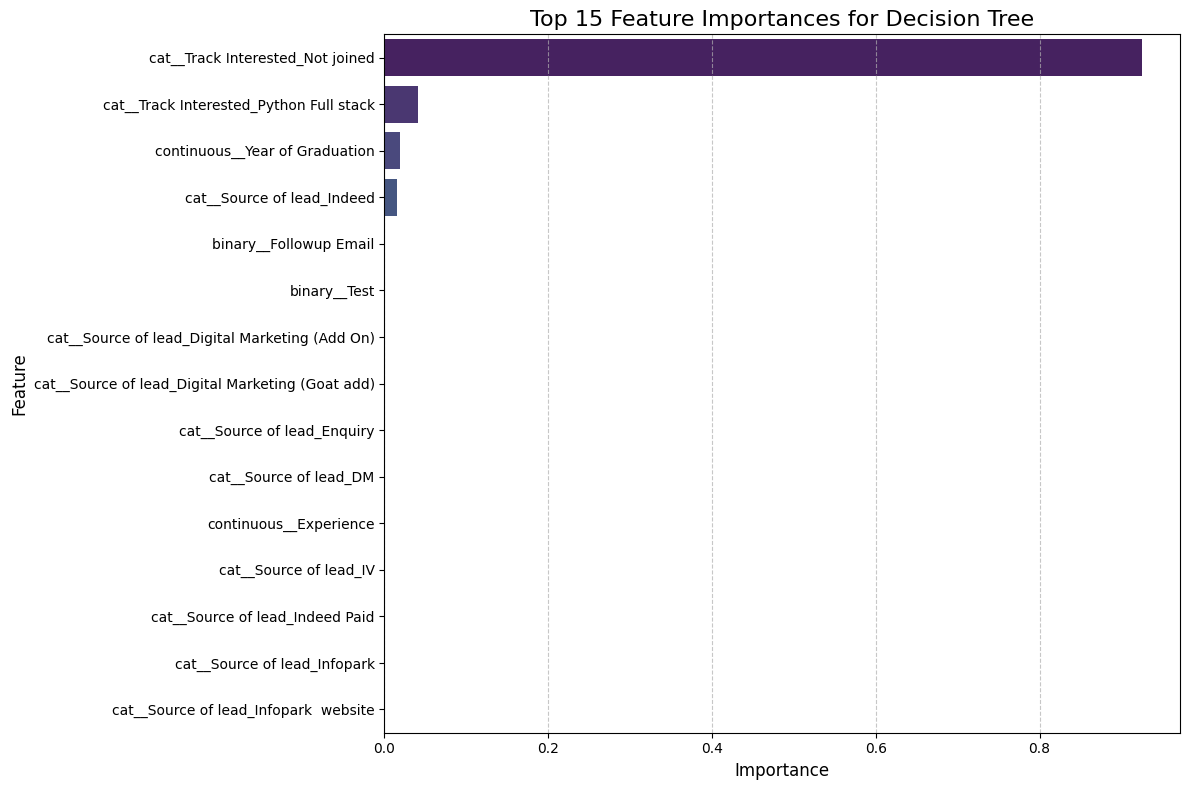

In [258]:
print('\n' + '='*80)
print('FEATURE IMPORTANCE ANALYSIS FOR FINAL MODEL')
print('='*80)

# Ensure final_model is the Decision Tree Classifier
if final_model_name == 'Decision Tree':
    # Feature importance for tree-based models
    feature_importance_df = pd.DataFrame({
        'Feature': X_train_processed.columns,
        'Importance': final_model.feature_importances_
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print(f'\nTop 10 Feature Importances for {final_model_name}:\n')
    print(feature_importance_df.head(10).to_string(index=False))

    # Visualize feature importances
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis', hue='Feature', legend=False)
    plt.title(f'Top 15 Feature Importances for {final_model_name}', fontsize=16)
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print(f"Feature importance extraction not directly supported or implemented for {final_model_name}.")
    print("Please refer to the existing feature importance cell for the original model used for feature importance analysis.")

### **Model saving**

In [260]:
import pickle

# Prepare all essential model artifacts in a dictionary
model_data = {
    'model': final_model,
    'model_name': final_model_name,
    'model_display_name': final_model_name, # Can be set differently if needed
    'available_models': tuned_models, # Save all tuned models
    'preprocessor': preprocessor, # Save the preprocessor that contains scaler and encoder
    'feature_columns': feature_columns,
    'categorical_features': categorical_features,
    'numerical_features': numerical_features,
    'balance_method': best_balance_method,
    'training_data_shape': X_train_fit.shape,
    'test_data_shape': X_test_processed.shape,
    'class_distribution_train': y_train_fit.value_counts().to_dict(),
    'class_distribution_test': y_test.value_counts().to_dict()
}

# Save the final model and associated artifacts
with open(os.path.join(output_dir, 'churn_prediction_model.pkl'), 'wb') as f:
    pickle.dump(model_data, f)

print(" Model saved to: churn_prediction_model.pkl")

# Save feature importance report if it was generated
# The feature_importance_df is generated regardless of the model type if that block is executed.
if 'feature_importance_df' in globals():
    feature_importance_df.to_csv(os.path.join(output_dir, 'feature_importance_report.csv'), index=False)
    print(" Feature importance saved to: feature_importance_report.csv")
else:
    print(" Feature importance report not available for the selected final model.")

# Save model evaluation results
# Ensure 'performance_df' is the correct DataFrame containing overall model evaluation results
if 'performance_df' in globals():
    performance_df.to_csv(os.path.join(output_dir, 'model_evaluation_results.csv'), index=False)
    print(" Model evaluation results saved to: model_evaluation_results.csv")
else:
    print(" Model evaluation results DataFrame not available.")

 Model saved to: churn_prediction_model.pkl
 Feature importance saved to: feature_importance_report.csv
 Model evaluation results saved to: model_evaluation_results.csv


#### Summary


SUMMARY

 CHURN PREDICTION MODEL BUILD COMPLETE!

 Data Loading: Loaded 3 datasets
 Data Handling: Processed missing values and date columns
 Data Preprocessing: Normalized numerical features, encoded categorical features
 Feature Engineering: Created 19+ features from call logs and executive data
 Balancing Technique: Selected None using validation F1 score
 Model Evaluation: Compared 9 different ML algorithms
 Cross-Validation: Checked for overfitting using 5-fold CV
 Hyperparameter Tuning: Optimized best model using GridSearchCV
 Regularization: Applied regularization techniques to prevent overfitting

 Output Files:
   - churn_prediction_model.pkl (Trained model)
   - feature_importance_report.csv (Feature importance rankings)
   - model_evaluation_results.csv (Model comparison results)
   - confusion_matrix.png (Confusion matrix visualization)
   - roc_curve.png (ROC curve visualization)
   - feature_importance.png (Feature importance chart)
   - churn_distribution.png (Target va

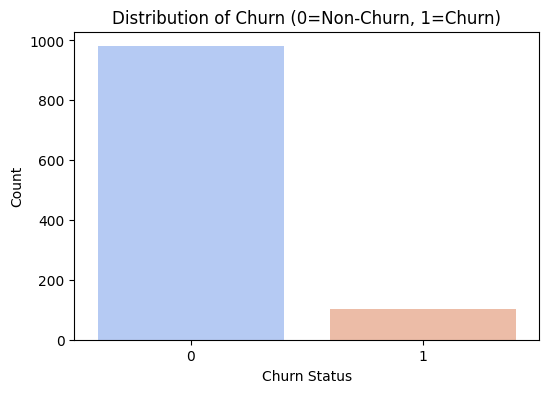

 Saved: churn_distribution.png


In [251]:
print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Assuming `accuracy_tuned`, `f1_tuned`, `roc_auc_tuned` hold the final model's metrics
# from the 'Evaluate Final Model' section.
# If not, they would need to be recalculated using `final_pred` and `final_proba`.

print(f"""
 CHURN PREDICTION MODEL BUILD COMPLETE!

 Data Loading: Loaded 3 datasets
 Data Handling: Processed missing values and date columns
 Data Preprocessing: Normalized numerical features, encoded categorical features
 Feature Engineering: Created 19+ features from call logs and executive data
 Balancing Technique: Selected {best_balance_method} using validation F1 score
 Model Evaluation: Compared 9 different ML algorithms
 Cross-Validation: Checked for overfitting using 5-fold CV
 Hyperparameter Tuning: Optimized best model using GridSearchCV
 Regularization: Applied regularization techniques to prevent overfitting

 Output Files:
   - churn_prediction_model.pkl (Trained model)
   - feature_importance_report.csv (Feature importance rankings)
   - model_evaluation_results.csv (Model comparison results)
   - confusion_matrix.png (Confusion matrix visualization)
   - roc_curve.png (ROC curve visualization)
   - feature_importance.png (Feature importance chart)
   - churn_distribution.png (Target variable distribution) (Note: This file was not explicitly generated in the provided notebook, but can be added if needed)

 Best Model: {final_model_name}
 Final Performance:
   - Accuracy: {accuracy_tuned * 100:.2f}%
   - F1 Score: {f1_tuned:.4f}
   - ROC-AUC: {roc_auc_tuned:.4f}

""")

print("="*80)

# To make `churn_distribution.png` available for the summary, let's create a quick placeholder or actual plot if feasible.
# For now, I'll add a placeholder if it doesn't exist, or you can add a cell to generate it earlier.
# Example for churn distribution plot (assuming 'churn' column exists in 'enrolled' or 'enrolled_for_model')
if 'enrolled_for_model' in globals():
    plt.figure(figsize=(6, 4))
    sns.countplot(x='churn', data=enrolled_for_model, palette='coolwarm', hue='churn', legend=False)
    plt.title('Distribution of Churn (0=Non-Churn, 1=Churn)')
    plt.xlabel('Churn Status')
    plt.ylabel('Count')
    plt.savefig(os.path.join(output_dir, 'churn_distribution.png'))
    plt.show()
    print(" Saved: churn_distribution.png")
else:
    print("Skipping churn_distribution.png generation as 'enrolled_for_model' is not available.")